In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


RANDOM_SEED = 52
rng = np.random.default_rng(RANDOM_SEED)


def make_age_group(age):
    if pd.isna(age):
        return "UNKNOWN"
    if age < 18:
        return "UNDER_18"
    if age <= 24:
        return "18_24"
    if age <= 34:
        return "25_34"
    if age <= 44:
        return "35_44"
    if age <= 54:
        return "45_54"
    if age <= 64:
        return "55_64"
    return "65_PLUS"


def prepare_income_features(df):
    df = df.copy()

    df = df.dropna(subset=["sex"])

    df["segment"] = df["segment"].fillna("UNKNOWN").astype(str)
    df["sex"] = df["sex"].astype(str)

    df["seniority_months"] = pd.to_numeric(df["seniority_months"], errors="coerce")
    df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
    df = df.dropna(subset=["seniority_months"])
    df["seniority_months"] = df["seniority_months"].round().astype("float64")

    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[
        (df["age"] < 14) | (df["age"] > 95),
        "age"
    ] = np.nan
    df = df.dropna(subset=["age"])
    df["age"] = df["age"].round().astype("float64")

    df["age_group"] = df["age"].apply(make_age_group)

    prefixes = ("dep-", "card-", "rko-", "loan-", "srv-", "biz-")

    product_cols = [
        col for col in df.columns
        if col.startswith(prefixes)
    ]

    dep_cols = [col for col in product_cols if col.startswith("dep-")]
    card_cols = [col for col in product_cols if col.startswith("card-")]
    rko_cols = [col for col in product_cols if col.startswith("rko-")]
    loan_cols = [col for col in product_cols if col.startswith("loan-")]
    srv_cols = [col for col in product_cols if col.startswith("srv-")]
    biz_cols = [col for col in product_cols if col.startswith("biz-")]

    df["products_count"] = df[product_cols].sum(axis=1)

    df["dep_count"] = df[dep_cols].sum(axis=1) if dep_cols else 0
    df["card_count"] = df[card_cols].sum(axis=1) if card_cols else 0
    df["rko_count"] = df[rko_cols].sum(axis=1) if rko_cols else 0
    df["loan_count"] = df[loan_cols].sum(axis=1) if loan_cols else 0
    df["srv_count"] = df[srv_cols].sum(axis=1) if srv_cols else 0
    df["biz_count"] = df[biz_cols].sum(axis=1) if biz_cols else 0

    df["has_dep"] = (df["dep_count"] > 0).astype(int)
    df["has_card"] = (df["card_count"] > 0).astype(int)
    df["has_rko"] = (df["rko_count"] > 0).astype(int)
    df["has_loan"] = (df["loan_count"] > 0).astype(int)
    df["has_srv"] = (df["srv_count"] > 0).astype(int)
    df["has_biz"] = (df["biz_count"] > 0).astype(int)

    def product_profile(row):
        if row["products_count"] == 0:
            return "NO_PRODUCTS"

        profile = []

        if row["has_dep"]:
            profile.append("DEP")
        if row["has_card"]:
            profile.append("CARD")
        if row["has_rko"]:
            profile.append("RKO")
        if row["has_loan"]:
            profile.append("LOAN")
        if row["has_srv"]:
            profile.append("SRV")
        if row["has_biz"]:
            profile.append("BIZ")

        return "_".join(profile)

    df["product_profile"] = df.apply(product_profile, axis=1)

    return df, product_cols


def calculate_income_metrics(y_true_log, y_pred_log, title="Metrics"):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    medae = median_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmsle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5
    r2_log = r2_score(y_true_log, y_pred_log)

    print(f"\n=== {title} ===")
    print(f"Rows: {len(y_true):,}")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MedianAE: {medae:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R2 log-income: {r2_log:.4f}")

    return {
        "rows": len(y_true),
        "mae": mae,
        "rmse": rmse,
        "median_ae": medae,
        "mape": mape,
        "rmsle": rmsle,
        "r2_log": r2_log
    }


def generate_income_with_train_test(path):
    df = pd.read_csv(path)

    df, product_cols = prepare_income_features(df)

    known_mask = df["income"].notna() & (df["income"] > 0)
    known_df = df.loc[known_mask].copy()

    lower = known_df["income"].quantile(0.005)
    upper = known_df["income"].quantile(0.995)

    known_df = known_df[
        (known_df["income"] >= lower) &
        (known_df["income"] <= upper)
    ].copy()

    cat_features = [
        "sex",
        "segment",
        "age_group",
        "product_profile"
    ]

    num_features = [
        "age",
        "is_new_customer",
        "seniority_months",
        "products_count",
        "dep_count",
        "card_count",
        "rko_count",
        "loan_count",
        "srv_count",
        "biz_count",
        "has_dep",
        "has_card",
        "has_rko",
        "has_loan",
        "has_srv",
        "has_biz"
    ] + product_cols

    features = cat_features + num_features

    for col in num_features:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")
        known_df[col] = pd.to_numeric(known_df[col], errors="coerce").astype("float64")

    X = known_df[features]
    y = np.log1p(known_df["income"])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                cat_features
            )
        ],
        remainder="passthrough",
        sparse_threshold=0
    )

    model = HistGradientBoostingRegressor(
        max_iter=1000,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=RANDOM_SEED
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    test_pred_log = pipeline.predict(X_test)

    deterministic_metrics = calculate_income_metrics(
        y_true_log=y_test,
        y_pred_log=test_pred_log,
        title="Deterministic model on test"
    )

    train_pred_log = pipeline.predict(X_train)

    train_residual_df = X_train.copy()
    train_residual_df["income_residual"] = y_train - train_pred_log

    train_residual_df["residual_group"] = (
        train_residual_df["segment"].astype(str) + "_" +
        train_residual_df["age_group"].astype(str) + "_" +
        train_residual_df["product_profile"].astype(str)
    )

    global_residuals = train_residual_df["income_residual"].values

    residuals_by_group = {
        group: values["income_residual"].values
        for group, values in train_residual_df.groupby("residual_group")
        if len(values) >= 30
    }

    residuals_by_segment_age = {
        group: values["income_residual"].values
        for group, values in train_residual_df.groupby(["segment", "age_group"])
        if len(values) >= 30
    }

    test_sampling_df = X_test.copy()
    test_sampling_df["residual_group"] = (
        test_sampling_df["segment"].astype(str) + "_" +
        test_sampling_df["age_group"].astype(str) + "_" +
        test_sampling_df["product_profile"].astype(str)
    )

    synthetic_test_log = []

    for pos, (_, row) in enumerate(test_sampling_df.iterrows()):
        base_prediction = test_pred_log[pos]
        group = row["residual_group"]

        if group in residuals_by_group:
            residual_pool = residuals_by_group[group]
        else:
            fallback_key = (row["segment"], row["age_group"])
            residual_pool = residuals_by_segment_age.get(
                fallback_key,
                global_residuals
            )

        sampled_residual = rng.choice(residual_pool)
        extra_noise = rng.normal(0, 0.03)

        synthetic_test_log.append(
            base_prediction + sampled_residual + extra_noise
        )

    synthetic_test_log = np.array(synthetic_test_log)

    synthetic_metrics = calculate_income_metrics(
        y_true_log=y_test,
        y_pred_log=synthetic_test_log,
        title="Synthetic income on test"
    )

    X_all = df[features]
    pred_all_log = pipeline.predict(X_all)

    df["residual_group"] = (
        df["segment"].astype(str) + "_" +
        df["age_group"].astype(str) + "_" +
        df["product_profile"].astype(str)
    )

    synthetic_log_incomes = []

    for pos, (_, row) in enumerate(df.iterrows()):
        base_prediction = pred_all_log[pos]
        group = row["residual_group"]

        if group in residuals_by_group:
            residual_pool = residuals_by_group[group]
        else:
            fallback_key = (row["segment"], row["age_group"])
            residual_pool = residuals_by_segment_age.get(
                fallback_key,
                global_residuals
            )

        sampled_residual = rng.choice(residual_pool)
        extra_noise = rng.normal(0, 0.03)

        synthetic_log_incomes.append(
            base_prediction + sampled_residual + extra_noise
        )

    income_generated = np.expm1(synthetic_log_incomes)
    income_generated = np.clip(income_generated, lower, upper)

    df["income_model_prediction"] = np.round(np.expm1(pred_all_log), 2)

    df["income_generated"] = np.nan

    missing_mask = df["income"].isna() | (df["income"] <= 0)

    df.loc[missing_mask, "income_generated"] = np.round(
        income_generated[missing_mask],
        2
    )

    df["income_filled"] = df["income"]

    df.loc[missing_mask, "income_filled"] = df.loc[
        missing_mask,
        "income_generated"
    ]

    df["income_was_generated"] = missing_mask.astype(int)

    df = df.drop(columns=["residual_group"], errors="ignore")

    metrics = {
        "deterministic_test": deterministic_metrics,
        "synthetic_test": synthetic_metrics
    }

    return df, pipeline, metrics


path = "raw/train_wide.csv"

df_income, income_model, income_metrics = generate_income_with_train_test(path)

df_income.to_csv(
    "processed/v1/train_wide_with_income_test.csv",
    index=False
)

print("\nSaved:")
print("processed/v1/train_wide_with_income_test.csv")


=== Deterministic model on test ===
Rows: 57,058
MAE: 56,696.55
RMSE: 87,358.19
MedianAE: 38,907.89
MAPE: 48.19%
RMSLE: 0.5567
R2 log-income: 0.0927

=== Synthetic income on test ===
Rows: 57,058
MAE: 83,230.58
RMSE: 120,932.07
MedianAE: 56,163.41
MAPE: 77.49%
RMSLE: 0.7869
R2 log-income: -0.8126

Saved:
processed/v1/train_wide_with_income_test.csv


In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


# =========================
# CONFIG
# =========================

RAW_PATH = "raw/train_wide.csv"
OUTPUT_PATH = "processed/v1/train_wide_with_income_test.csv"

RANDOM_SEED = 52
rng = np.random.default_rng(RANDOM_SEED)

# Чем заполнять пропущенный income:
# "deterministic" — прогноз модели без шума, лучше для восстановления пропусков
# "synthetic" — прогноз + residual noise, лучше для реалистичного синтетического разброса
FILL_MODE = "deterministic"


# =========================
# FEATURE ENGINEERING
# =========================

def make_age_group(age):
    if pd.isna(age):
        return "UNKNOWN"
    if age < 18:
        return "UNDER_18"
    if age <= 24:
        return "18_24"
    if age <= 34:
        return "25_34"
    if age <= 44:
        return "35_44"
    if age <= 54:
        return "45_54"
    if age <= 64:
        return "55_64"
    return "65_PLUS"


def prepare_income_features(df):
    df = df.copy()

    # sex: удаляем редкие пропуски
    df = df.dropna(subset=["sex"])
    df["sex"] = df["sex"].astype(str)

    # segment: UNKNOWN вместо NaN
    df["segment"] = df["segment"].fillna("UNKNOWN").astype(str)

    # seniority_months
    df["seniority_months"] = pd.to_numeric(df["seniority_months"], errors="coerce")
    df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
    df = df.dropna(subset=["seniority_months"])
    df["seniority_months"] = df["seniority_months"].round().astype("float64")

    # age
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[
        (df["age"] < 14) | (df["age"] > 95),
        "age"
    ] = np.nan
    df = df.dropna(subset=["age"])
    df["age"] = df["age"].round().astype("float64")

    df["age_group"] = df["age"].apply(make_age_group)

    # is_new_customer
    df["is_new_customer"] = pd.to_numeric(
        df["is_new_customer"],
        errors="coerce"
    ).fillna(0).astype("float64")

    # product columns
    prefixes = ("dep-", "card-", "rko-", "loan-", "srv-", "biz-")

    product_cols = [
        col for col in df.columns
        if col.startswith(prefixes)
    ]

    for col in product_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float64")

    dep_cols = [col for col in product_cols if col.startswith("dep-")]
    card_cols = [col for col in product_cols if col.startswith("card-")]
    rko_cols = [col for col in product_cols if col.startswith("rko-")]
    loan_cols = [col for col in product_cols if col.startswith("loan-")]
    srv_cols = [col for col in product_cols if col.startswith("srv-")]
    biz_cols = [col for col in product_cols if col.startswith("biz-")]

    # aggregate product features
    df["products_count"] = df[product_cols].sum(axis=1) if product_cols else 0

    df["dep_count"] = df[dep_cols].sum(axis=1) if dep_cols else 0
    df["card_count"] = df[card_cols].sum(axis=1) if card_cols else 0
    df["rko_count"] = df[rko_cols].sum(axis=1) if rko_cols else 0
    df["loan_count"] = df[loan_cols].sum(axis=1) if loan_cols else 0
    df["srv_count"] = df[srv_cols].sum(axis=1) if srv_cols else 0
    df["biz_count"] = df[biz_cols].sum(axis=1) if biz_cols else 0

    df["has_dep"] = (df["dep_count"] > 0).astype(int)
    df["has_card"] = (df["card_count"] > 0).astype(int)
    df["has_rko"] = (df["rko_count"] > 0).astype(int)
    df["has_loan"] = (df["loan_count"] > 0).astype(int)
    df["has_srv"] = (df["srv_count"] > 0).astype(int)
    df["has_biz"] = (df["biz_count"] > 0).astype(int)

    def product_profile(row):
        if row["products_count"] == 0:
            return "NO_PRODUCTS"

        profile = []

        if row["has_dep"]:
            profile.append("DEP")
        if row["has_card"]:
            profile.append("CARD")
        if row["has_rko"]:
            profile.append("RKO")
        if row["has_loan"]:
            profile.append("LOAN")
        if row["has_srv"]:
            profile.append("SRV")
        if row["has_biz"]:
            profile.append("BIZ")

        return "_".join(profile)

    df["product_profile"] = df.apply(product_profile, axis=1)

    return df, product_cols


# =========================
# METRICS
# =========================

def calculate_income_metrics(y_true_log, y_pred_log, title="Metrics"):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    medae = median_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmsle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5
    r2_log = r2_score(y_true_log, y_pred_log)

    print(f"\n=== {title} ===")
    print(f"Rows: {len(y_true):,}")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MedianAE: {medae:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R2 log-income: {r2_log:.4f}")

    return {
        "title": title,
        "rows": len(y_true),
        "mae": mae,
        "rmse": rmse,
        "median_ae": medae,
        "mape": mape,
        "rmsle": rmsle,
        "r2_log": r2_log
    }


def calculate_filtered_metrics(
    y_true_log,
    deterministic_pred_log,
    synthetic_pred_log,
    upper_quantile
):
    y_true = np.expm1(y_true_log)

    upper_limit = np.quantile(y_true, upper_quantile)
    keep_mask = y_true <= upper_limit

    print("\n" + "=" * 70)
    print(f"FILTER: remove top {round((1 - upper_quantile) * 100, 2)}% by real income")
    print(f"Income limit q{int(upper_quantile * 100)}: {upper_limit:,.2f}")
    print(f"Rows before: {len(y_true):,}")
    print(f"Rows after: {keep_mask.sum():,}")
    print(f"Rows removed: {(~keep_mask).sum():,}")
    print("=" * 70)

    det_metrics = calculate_income_metrics(
        y_true_log=np.array(y_true_log)[keep_mask],
        y_pred_log=np.array(deterministic_pred_log)[keep_mask],
        title=f"Deterministic model on filtered test q{int(upper_quantile * 100)}"
    )

    syn_metrics = calculate_income_metrics(
        y_true_log=np.array(y_true_log)[keep_mask],
        y_pred_log=np.array(synthetic_pred_log)[keep_mask],
        title=f"Synthetic income on filtered test q{int(upper_quantile * 100)}"
    )

    return det_metrics, syn_metrics


# =========================
# MAIN PIPELINE
# =========================

df = pd.read_csv(RAW_PATH)

print("Original rows:", len(df))

df, product_cols = prepare_income_features(df)

print("Rows after feature cleaning:", len(df))

known_mask = df["income"].notna() & (df["income"] > 0)
known_df = df.loc[known_mask].copy()

print("Rows with known income:", len(known_df))
print("Rows with missing income:", (~known_mask).sum())

# cut extreme income values only for training/evaluation
lower = known_df["income"].quantile(0.005)
upper = known_df["income"].quantile(0.995)

known_df = known_df[
    (known_df["income"] >= lower) &
    (known_df["income"] <= upper)
].copy()

print(f"Training income lower q0.5%: {lower:,.2f}")
print(f"Training income upper q99.5%: {upper:,.2f}")
print("Known income rows after extreme cut:", len(known_df))

cat_features = [
    "sex",
    "segment",
    "age_group",
    "product_profile"
]

num_features = [
    "age",
    "is_new_customer",
    "seniority_months",
    "products_count",
    "dep_count",
    "card_count",
    "rko_count",
    "loan_count",
    "srv_count",
    "biz_count",
    "has_dep",
    "has_card",
    "has_rko",
    "has_loan",
    "has_srv",
    "has_biz"
] + product_cols

features = cat_features + num_features

# force numeric dtype
for col in num_features:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")
    known_df[col] = pd.to_numeric(known_df[col], errors="coerce").astype("float64")

X = known_df[features]
y = np.log1p(known_df["income"])

# stratify by segment if possible
segment_counts = known_df["segment"].value_counts()
stratify_col = known_df["segment"] if segment_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=stratify_col
)

print("\nTrain rows:", len(X_train))
print("Test rows:", len(X_test))

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_features
        )
    ],
    remainder="passthrough",
    sparse_threshold=0
)

model = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=RANDOM_SEED
)

income_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# train
income_pipeline.fit(X_train, y_train)

# deterministic test prediction
test_pred_log = income_pipeline.predict(X_test)

deterministic_test_metrics = calculate_income_metrics(
    y_true_log=np.array(y_test),
    y_pred_log=np.array(test_pred_log),
    title="Deterministic model on full test"
)

# residuals from train only
train_pred_log = income_pipeline.predict(X_train)

train_residual_df = X_train.copy()
train_residual_df["income_residual"] = np.array(y_train) - train_pred_log

train_residual_df["residual_group"] = (
    train_residual_df["segment"].astype(str) + "_" +
    train_residual_df["age_group"].astype(str) + "_" +
    train_residual_df["product_profile"].astype(str)
)

global_residuals = train_residual_df["income_residual"].values

residuals_by_group = {
    group: values["income_residual"].values
    for group, values in train_residual_df.groupby("residual_group")
    if len(values) >= 30
}

residuals_by_segment_age = {
    group: values["income_residual"].values
    for group, values in train_residual_df.groupby(["segment", "age_group"])
    if len(values) >= 30
}

# synthetic test prediction
test_sampling_df = X_test.copy()
test_sampling_df["residual_group"] = (
    test_sampling_df["segment"].astype(str) + "_" +
    test_sampling_df["age_group"].astype(str) + "_" +
    test_sampling_df["product_profile"].astype(str)
)

synthetic_test_log = []

for pos, (_, row) in enumerate(test_sampling_df.iterrows()):
    base_prediction = test_pred_log[pos]
    group = row["residual_group"]

    if group in residuals_by_group:
        residual_pool = residuals_by_group[group]
    else:
        fallback_key = (row["segment"], row["age_group"])
        residual_pool = residuals_by_segment_age.get(
            fallback_key,
            global_residuals
        )

    sampled_residual = rng.choice(residual_pool)

    # можно уменьшать, если synthetic слишком шумный
    residual_strength = 1.0
    extra_noise_sigma = 0.03

    extra_noise = rng.normal(0, extra_noise_sigma)

    synthetic_test_log.append(
        base_prediction + residual_strength * sampled_residual + extra_noise
    )

synthetic_test_log = np.array(synthetic_test_log)

synthetic_test_metrics = calculate_income_metrics(
    y_true_log=np.array(y_test),
    y_pred_log=synthetic_test_log,
    title="Synthetic income on full test"
)

# filtered metrics: cut rich clients from test
filtered_metrics = {}

for q in [0.90, 0.95, 0.99]:
    det_m, syn_m = calculate_filtered_metrics(
        y_true_log=np.array(y_test),
        deterministic_pred_log=np.array(test_pred_log),
        synthetic_pred_log=np.array(synthetic_test_log),
        upper_quantile=q
    )

    filtered_metrics[f"deterministic_q{int(q * 100)}"] = det_m
    filtered_metrics[f"synthetic_q{int(q * 100)}"] = syn_m


# =========================
# GENERATE INCOME FOR FULL DATASET
# =========================

X_all = df[features]
pred_all_log = income_pipeline.predict(X_all)

df["income_model_prediction"] = np.round(np.expm1(pred_all_log), 2)

df["residual_group"] = (
    df["segment"].astype(str) + "_" +
    df["age_group"].astype(str) + "_" +
    df["product_profile"].astype(str)
)

synthetic_all_log = []

for pos, (_, row) in enumerate(df.iterrows()):
    base_prediction = pred_all_log[pos]
    group = row["residual_group"]

    if group in residuals_by_group:
        residual_pool = residuals_by_group[group]
    else:
        fallback_key = (row["segment"], row["age_group"])
        residual_pool = residuals_by_segment_age.get(
            fallback_key,
            global_residuals
        )

    sampled_residual = rng.choice(residual_pool)

    residual_strength = 1.0
    extra_noise_sigma = 0.03

    extra_noise = rng.normal(0, extra_noise_sigma)

    synthetic_all_log.append(
        base_prediction + residual_strength * sampled_residual + extra_noise
    )

income_synthetic_all = np.expm1(synthetic_all_log)
income_synthetic_all = np.clip(income_synthetic_all, lower, upper)

df["income_synthetic_prediction"] = np.round(income_synthetic_all, 2)

missing_mask = df["income"].isna() | (df["income"] <= 0)

df["income_generated"] = np.nan

if FILL_MODE == "deterministic":
    df.loc[missing_mask, "income_generated"] = df.loc[
        missing_mask,
        "income_model_prediction"
    ]
elif FILL_MODE == "synthetic":
    df.loc[missing_mask, "income_generated"] = df.loc[
        missing_mask,
        "income_synthetic_prediction"
    ]
else:
    raise ValueError("FILL_MODE must be either 'deterministic' or 'synthetic'.")

df["income_filled"] = df["income"]

df.loc[missing_mask, "income_filled"] = df.loc[
    missing_mask,
    "income_generated"
]

df["income_was_generated"] = missing_mask.astype(int)

df = df.drop(columns=["residual_group"], errors="ignore")

# save
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print("\nSaved:")
print(OUTPUT_PATH)

print("\nFill mode:", FILL_MODE)
print("Generated income rows:", int(df["income_was_generated"].sum()))

# metrics as dataframe
all_metrics = {
    "deterministic_full_test": deterministic_test_metrics,
    "synthetic_full_test": synthetic_test_metrics,
    **filtered_metrics
}

metrics_df = pd.DataFrame(all_metrics).T

print("\nMetrics summary:")
display(metrics_df)

Original rows: 376141
Rows after feature cleaning: 372501
Rows with known income: 288171
Rows with missing income: 84330
Training income lower q0.5%: 23,917.68
Training income upper q99.5%: 727,150.70
Known income rows after extreme cut: 285289

Train rows: 228231
Test rows: 57058

=== Deterministic model on full test ===
Rows: 57,058
MAE: 56,859.43
RMSE: 88,168.98
MedianAE: 38,742.66
MAPE: 48.10%
RMSLE: 0.5575
R2 log-income: 0.0943

=== Synthetic income on full test ===
Rows: 57,058
MAE: 83,649.78
RMSE: 121,718.37
MedianAE: 56,397.09
MAPE: 77.87%
RMSLE: 0.7909
R2 log-income: -0.8226

FILTER: remove top 10.0% by real income
Income limit q90: 236,366.01
Rows before: 57,058
Rows after: 51,352
Rows removed: 5,706

=== Deterministic model on filtered test q90 ===
Rows: 51,352
MAE: 39,270.43
RMSE: 48,182.88
MedianAE: 34,612.87
MAPE: 46.67%
RMSLE: 0.4758
R2 log-income: 0.0139

=== Synthetic income on filtered test q90 ===
Rows: 51,352
MAE: 69,880.20
RMSE: 100,571.56
MedianAE: 50,087.77
MAPE:

,title,rows,mae,rmse,median_ae,mape,rmsle,r2_log
deterministic_full_test,Deterministic model on full test,57058,56859.433597,88168.983412,38742.659197,48.096328,0.557515,0.09426
synthetic_full_test,Synthetic income on full test,57058,83649.778263,121718.373048,56397.087385,77.872288,0.790852,-0.822561
deterministic_q90,Deterministic model on filtered test q90,51352,39270.428229,48182.879248,34612.871807,46.669131,0.475773,0.013904
synthetic_q90,Synthetic income on filtered test q90,51352,69880.203199,100571.560874,50087.768829,79.957864,0.734147,-1.347933
deterministic_q95,Deterministic model on filtered test q95,54205,44691.856604,57515.689427,36666.295726,47.021708,0.498308,0.069015
synthetic_q95,Synthetic income on filtered test q95,54205,73646.626929,104196.267556,53002.456335,78.54827,0.749531,-1.106335
deterministic_q99,Deterministic model on filtered test q99,56487,52907.932467,75993.560944,38346.28166,47.793601,0.538095,0.092987
synthetic_q99,Synthetic income on filtered test q99,56487,80148.095848,113861.305181,55617.425442,77.901869,0.776507,-0.888804


In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


# =========================
# CONFIG
# =========================

RAW_PATH = "raw/train_wide.csv"
OUTPUT_PATH = "processed/v1/train_wide_with_income_test_cut_high_income.csv"

RANDOM_SEED = 52
rng = np.random.default_rng(RANDOM_SEED)

# Удаляем из обучения и теста клиентов с income выше этого квантиля.
# 0.95 = убрать верхние 5% по доходу.
TRAIN_INCOME_UPPER_QUANTILE = 0.9

# Нижний срез можно оставить очень мягким.
TRAIN_INCOME_LOWER_QUANTILE = 0.005

# Чем заполнять пропущенный income:
# "deterministic" — прогноз модели без шума, лучше для восстановления пропусков
# "synthetic" — прогноз + residual noise, лучше для реалистичного синтетического разброса
FILL_MODE = "deterministic"

# Настройки synthetic-шума
RESIDUAL_STRENGTH = 1.0
EXTRA_NOISE_SIGMA = 0.03


# =========================
# FEATURE ENGINEERING
# =========================

def make_age_group(age):
    if pd.isna(age):
        return "UNKNOWN"
    if age < 18:
        return "UNDER_18"
    if age <= 24:
        return "18_24"
    if age <= 34:
        return "25_34"
    if age <= 44:
        return "35_44"
    if age <= 54:
        return "45_54"
    if age <= 64:
        return "55_64"
    return "65_PLUS"


def prepare_income_features(df):
    df = df.copy()

    # sex: удаляем редкие пропуски
    df = df.dropna(subset=["sex"])
    df["sex"] = df["sex"].astype(str)

    # segment: UNKNOWN вместо NaN
    df["segment"] = df["segment"].fillna("UNKNOWN").astype(str)

    # seniority_months
    df["seniority_months"] = pd.to_numeric(df["seniority_months"], errors="coerce")
    df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
    df = df.dropna(subset=["seniority_months"])
    df["seniority_months"] = df["seniority_months"].round().astype("float64")

    # age
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[
        (df["age"] < 14) | (df["age"] > 95),
        "age"
    ] = np.nan
    df = df.dropna(subset=["age"])
    df["age"] = df["age"].round().astype("float64")

    df["age_group"] = df["age"].apply(make_age_group)

    # is_new_customer
    df["is_new_customer"] = pd.to_numeric(
        df["is_new_customer"],
        errors="coerce"
    ).fillna(0).astype("float64")

    # product columns
    prefixes = ("dep-", "card-", "rko-", "loan-", "srv-", "biz-")

    product_cols = [
        col for col in df.columns
        if col.startswith(prefixes)
    ]

    for col in product_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float64")

    dep_cols = [col for col in product_cols if col.startswith("dep-")]
    card_cols = [col for col in product_cols if col.startswith("card-")]
    rko_cols = [col for col in product_cols if col.startswith("rko-")]
    loan_cols = [col for col in product_cols if col.startswith("loan-")]
    srv_cols = [col for col in product_cols if col.startswith("srv-")]
    biz_cols = [col for col in product_cols if col.startswith("biz-")]

    # aggregate product features
    df["products_count"] = df[product_cols].sum(axis=1) if product_cols else 0

    df["dep_count"] = df[dep_cols].sum(axis=1) if dep_cols else 0
    df["card_count"] = df[card_cols].sum(axis=1) if card_cols else 0
    df["rko_count"] = df[rko_cols].sum(axis=1) if rko_cols else 0
    df["loan_count"] = df[loan_cols].sum(axis=1) if loan_cols else 0
    df["srv_count"] = df[srv_cols].sum(axis=1) if srv_cols else 0
    df["biz_count"] = df[biz_cols].sum(axis=1) if biz_cols else 0

    df["has_dep"] = (df["dep_count"] > 0).astype(int)
    df["has_card"] = (df["card_count"] > 0).astype(int)
    df["has_rko"] = (df["rko_count"] > 0).astype(int)
    df["has_loan"] = (df["loan_count"] > 0).astype(int)
    df["has_srv"] = (df["srv_count"] > 0).astype(int)
    df["has_biz"] = (df["biz_count"] > 0).astype(int)

    def product_profile(row):
        if row["products_count"] == 0:
            return "NO_PRODUCTS"

        profile = []

        if row["has_dep"]:
            profile.append("DEP")
        if row["has_card"]:
            profile.append("CARD")
        if row["has_rko"]:
            profile.append("RKO")
        if row["has_loan"]:
            profile.append("LOAN")
        if row["has_srv"]:
            profile.append("SRV")
        if row["has_biz"]:
            profile.append("BIZ")

        return "_".join(profile)

    df["product_profile"] = df.apply(product_profile, axis=1)

    return df, product_cols


# =========================
# METRICS
# =========================

def calculate_income_metrics(y_true_log, y_pred_log, title="Metrics"):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    medae = median_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmsle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5
    r2_log = r2_score(y_true_log, y_pred_log)

    print(f"\n=== {title} ===")
    print(f"Rows: {len(y_true):,}")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MedianAE: {medae:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R2 log-income: {r2_log:.4f}")

    return {
        "title": title,
        "rows": len(y_true),
        "mae": mae,
        "rmse": rmse,
        "median_ae": medae,
        "mape": mape,
        "rmsle": rmsle,
        "r2_log": r2_log
    }


def calculate_segment_metrics(X_test, y_true_log, y_pred_log, title="Segment metrics"):
    temp = X_test.copy()
    temp["y_true"] = np.expm1(y_true_log)
    temp["y_pred"] = np.expm1(y_pred_log)

    rows = []

    for segment, g in temp.groupby("segment"):
        if len(g) < 30:
            continue

        mae = mean_absolute_error(g["y_true"], g["y_pred"])
        rmse = mean_squared_error(g["y_true"], g["y_pred"]) ** 0.5
        medae = median_absolute_error(g["y_true"], g["y_pred"])
        mape = np.mean(np.abs((g["y_true"] - g["y_pred"]) / g["y_true"])) * 100
        rmsle = mean_squared_error(
            np.log1p(g["y_true"]),
            np.log1p(g["y_pred"])
        ) ** 0.5

        rows.append({
            "segment": segment,
            "rows": len(g),
            "mae": mae,
            "rmse": rmse,
            "median_ae": medae,
            "mape": mape,
            "rmsle": rmsle
        })

    result = pd.DataFrame(rows).sort_values("mae", ascending=False)

    print(f"\n=== {title} ===")
    display(result)

    return result


# =========================
# MAIN PIPELINE
# =========================

df = pd.read_csv(RAW_PATH)

print("Original rows:", len(df))

df, product_cols = prepare_income_features(df)

print("Rows after feature cleaning:", len(df))

known_mask = df["income"].notna() & (df["income"] > 0)
known_df_raw = df.loc[known_mask].copy()

print("Rows with known income before high-income cut:", len(known_df_raw))
print("Rows with missing income:", int((~known_mask).sum()))

# =========================
# CUT HIGH INCOME BEFORE TRAIN/TEST
# =========================

lower = known_df_raw["income"].quantile(TRAIN_INCOME_LOWER_QUANTILE)
upper = known_df_raw["income"].quantile(TRAIN_INCOME_UPPER_QUANTILE)

known_df = known_df_raw[
    (known_df_raw["income"] >= lower) &
    (known_df_raw["income"] <= upper)
].copy()

removed_known_rows = len(known_df_raw) - len(known_df)

print("\nIncome cut before train/test:")
print(f"Lower quantile q{TRAIN_INCOME_LOWER_QUANTILE}: {lower:,.2f}")
print(f"Upper quantile q{TRAIN_INCOME_UPPER_QUANTILE}: {upper:,.2f}")
print("Known rows after income cut:", len(known_df))
print("Known rows removed:", removed_known_rows)
print(f"Removed share: {removed_known_rows / len(known_df_raw) * 100:.2f}%")

cat_features = [
    "sex",
    "segment",
    "age_group",
    "product_profile"
]

num_features = [
    "age",
    "is_new_customer",
    "seniority_months",
    "products_count",
    "dep_count",
    "card_count",
    "rko_count",
    "loan_count",
    "srv_count",
    "biz_count",
    "has_dep",
    "has_card",
    "has_rko",
    "has_loan",
    "has_srv",
    "has_biz"
] + product_cols

features = cat_features + num_features

# force numeric dtype
for col in num_features:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")
    known_df[col] = pd.to_numeric(known_df[col], errors="coerce").astype("float64")

X = known_df[features]
y = np.log1p(known_df["income"])

# stratify by segment if possible
segment_counts = known_df["segment"].value_counts()
stratify_col = known_df["segment"] if segment_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=stratify_col
)

print("\nTrain rows:", len(X_train))
print("Test rows:", len(X_test))
print(f"Test max real income after cut: {np.expm1(y_test).max():,.2f}")

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_features
        )
    ],
    remainder="passthrough",
    sparse_threshold=0
)

model = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=RANDOM_SEED
)

income_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# train
income_pipeline.fit(X_train, y_train)

# =========================
# TRAIN METRICS
# =========================

train_pred_log = income_pipeline.predict(X_train)

deterministic_train_metrics = calculate_income_metrics(
    y_true_log=np.array(y_train),
    y_pred_log=np.array(train_pred_log),
    title=f"Deterministic model on train after removing high income > q{int(TRAIN_INCOME_UPPER_QUANTILE * 100)}"
)

train_segment_metrics = calculate_segment_metrics(
    X_test=X_train,
    y_true_log=np.array(y_train),
    y_pred_log=np.array(train_pred_log),
    title="Deterministic train metrics by segment"
)

# deterministic test prediction
test_pred_log = income_pipeline.predict(X_test)

deterministic_test_metrics = calculate_income_metrics(
    y_true_log=np.array(y_test),
    y_pred_log=np.array(test_pred_log),
    title=f"Deterministic model on test after removing high income > q{int(TRAIN_INCOME_UPPER_QUANTILE * 100)}"
)

segment_metrics = calculate_segment_metrics(
    X_test=X_test,
    y_true_log=np.array(y_test),
    y_pred_log=np.array(test_pred_log),
    title="Deterministic test metrics by segment"
)


train_residual_df = X_train.copy()
train_residual_df["income_residual"] = np.array(y_train) - train_pred_log

train_residual_df["residual_group"] = (
    train_residual_df["segment"].astype(str) + "_" +
    train_residual_df["age_group"].astype(str) + "_" +
    train_residual_df["product_profile"].astype(str)
)

global_residuals = train_residual_df["income_residual"].values

residuals_by_group = {
    group: values["income_residual"].values
    for group, values in train_residual_df.groupby("residual_group")
    if len(values) >= 30
}

residuals_by_segment_age = {
    group: values["income_residual"].values
    for group, values in train_residual_df.groupby(["segment", "age_group"])
    if len(values) >= 30
}

# synthetic test prediction
test_sampling_df = X_test.copy()
test_sampling_df["residual_group"] = (
    test_sampling_df["segment"].astype(str) + "_" +
    test_sampling_df["age_group"].astype(str) + "_" +
    test_sampling_df["product_profile"].astype(str)
)

synthetic_test_log = []

for pos, (_, row) in enumerate(test_sampling_df.iterrows()):
    base_prediction = test_pred_log[pos]
    group = row["residual_group"]

    if group in residuals_by_group:
        residual_pool = residuals_by_group[group]
    else:
        fallback_key = (row["segment"], row["age_group"])
        residual_pool = residuals_by_segment_age.get(
            fallback_key,
            global_residuals
        )

    sampled_residual = rng.choice(residual_pool)
    extra_noise = rng.normal(0, EXTRA_NOISE_SIGMA)

    synthetic_test_log.append(
        base_prediction + RESIDUAL_STRENGTH * sampled_residual + extra_noise
    )

synthetic_test_log = np.array(synthetic_test_log)

synthetic_test_metrics = calculate_income_metrics(
    y_true_log=np.array(y_test),
    y_pred_log=synthetic_test_log,
    title=f"Synthetic income on test after removing high income > q{int(TRAIN_INCOME_UPPER_QUANTILE * 100)}"
)


# =========================
# GENERATE INCOME FOR FULL DATASET
# =========================

X_all = df[features]
pred_all_log = income_pipeline.predict(X_all)

df["income_model_prediction"] = np.round(np.expm1(pred_all_log), 2)

df["residual_group"] = (
    df["segment"].astype(str) + "_" +
    df["age_group"].astype(str) + "_" +
    df["product_profile"].astype(str)
)

synthetic_all_log = []

for pos, (_, row) in enumerate(df.iterrows()):
    base_prediction = pred_all_log[pos]
    group = row["residual_group"]

    if group in residuals_by_group:
        residual_pool = residuals_by_group[group]
    else:
        fallback_key = (row["segment"], row["age_group"])
        residual_pool = residuals_by_segment_age.get(
            fallback_key,
            global_residuals
        )

    sampled_residual = rng.choice(residual_pool)
    extra_noise = rng.normal(0, EXTRA_NOISE_SIGMA)

    synthetic_all_log.append(
        base_prediction + RESIDUAL_STRENGTH * sampled_residual + extra_noise
    )

income_synthetic_all = np.expm1(synthetic_all_log)

# Так как модель обучалась без верхнего хвоста, синтетику тоже ограничиваем тем же upper.
income_synthetic_all = np.clip(income_synthetic_all, lower, upper)

df["income_synthetic_prediction"] = np.round(income_synthetic_all, 2)

missing_mask = df["income"].isna() | (df["income"] <= 0)

df["income_generated"] = np.nan

if FILL_MODE == "deterministic":
    df.loc[missing_mask, "income_generated"] = df.loc[
        missing_mask,
        "income_model_prediction"
    ]
elif FILL_MODE == "synthetic":
    df.loc[missing_mask, "income_generated"] = df.loc[
        missing_mask,
        "income_synthetic_prediction"
    ]
else:
    raise ValueError("FILL_MODE must be either 'deterministic' or 'synthetic'.")

df["income_filled"] = df["income"]

df.loc[missing_mask, "income_filled"] = df.loc[
    missing_mask,
    "income_generated"
]

df["income_was_generated"] = missing_mask.astype(int)

df = df.drop(columns=["residual_group"], errors="ignore")

# save
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print("\nSaved:")
print(OUTPUT_PATH)

print("\nFill mode:", FILL_MODE)
print("Generated income rows:", int(df["income_was_generated"].sum()))

all_metrics = {
    "deterministic_train_after_high_income_cut": deterministic_train_metrics,
    "deterministic_test_after_high_income_cut": deterministic_test_metrics,
    "synthetic_test_after_high_income_cut": synthetic_test_metrics
}

metrics_df = pd.DataFrame(all_metrics).T

print("\nMetrics summary:")
display(metrics_df)

Original rows: 376141
Rows after feature cleaning: 372501
Rows with known income before high-income cut: 288171
Rows with missing income: 84330

Income cut before train/test:
Lower quantile q0.005: 23,917.68
Upper quantile q0.85: 206,312.55
Known rows after income cut: 243504
Known rows removed: 44667
Removed share: 15.50%

Train rows: 194803
Test rows: 48701
Test max real income after cut: 206,306.91

=== Deterministic model on train after removing high income > q85 ===
Rows: 194,803
MAE: 34,625.06
RMSE: 43,096.55
MedianAE: 29,516.83
MAPE: 39.09%
RMSLE: 0.4370
R2 log-income: 0.0667

=== Deterministic train metrics by segment ===


,segment,rows,mae,rmse,median_ae,mape,rmsle
2,VIP,16655,36945.605384,44402.643915,33758.144748,37.145030,0.411442
0,INDIVIDUALS,128790,34997.688880,43349.684551,30052.613091,39.023077,0.434774
1,STUDENTS,49346,32869.113772,41971.760499,26982.874912,39.926388,0.450858



=== Deterministic model on test after removing high income > q85 ===
Rows: 48,701
MAE: 34,662.49
RMSE: 43,112.21
MedianAE: 29,571.87
MAPE: 39.31%
RMSLE: 0.4388
R2 log-income: 0.0625

=== Deterministic test metrics by segment ===


,segment,rows,mae,rmse,median_ae,mape,rmsle
2,VIP,4164,37135.426912,44720.687980,33395.243388,37.559235,0.415475
0,INDIVIDUALS,32198,35055.943541,43415.268524,30190.924964,39.144799,0.436128
1,STUDENTS,12336,32797.175973,41741.332698,26938.048924,40.323483,0.452994



=== Synthetic income on test after removing high income > q85 ===
Rows: 48,701
MAE: 47,936.83
RMSE: 59,961.45
MedianAE: 40,351.40
MAPE: 56.59%
RMSLE: 0.6213
R2 log-income: -0.8796

Saved:
processed/v1/train_wide_with_income_test_cut_high_income.csv

Fill mode: deterministic
Generated income rows: 84330

Metrics summary:


,title,rows,mae,rmse,median_ae,mape,rmsle,r2_log
deterministic_train_after_high_income_cut,Deterministic model on train after removing hi...,194803,34625.058625,43096.547989,29516.83213,39.090625,0.436973,0.066688
deterministic_test_after_high_income_cut,Deterministic model on test after removing hig...,48701,34662.49458,43112.207685,29571.867553,39.311286,0.438771,0.062516
synthetic_test_after_high_income_cut,Synthetic income on test after removing high i...,48701,47936.83196,59961.450049,40351.39622,56.586912,0.621282,-0.879604


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)

path = 'processed/v1/train_wide_with_income.csv'

df = pd.read_csv(path)

df.head()

,user_id,sex,age,is_new_customer,seniority_months,segment,dep-7,card-2,dep-5,card-1,...,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3,income_generated,income_filled
0,657788,F,42,0.0,114,INDIVIDUALS,0,1,0,0,...,0,0,0,0,0,0,0,0,169291.557763,132559.350000
1,657795,M,44,0.0,114,INDIVIDUALS,0,1,0,0,...,0,0,0,0,0,0,0,0,161653.485356,81399.570000
2,657790,M,42,0.0,114,INDIVIDUALS,0,0,0,1,...,0,0,0,1,0,0,1,1,110673.737252,110673.737252
3,657794,F,49,0.0,114,VIP,0,1,0,0,...,0,0,0,0,0,0,0,0,208172.272907,102189.000000
4,657789,M,36,0.0,91,VIP,0,1,0,0,...,0,0,0,1,0,0,0,0,89691.098605,153725.490000


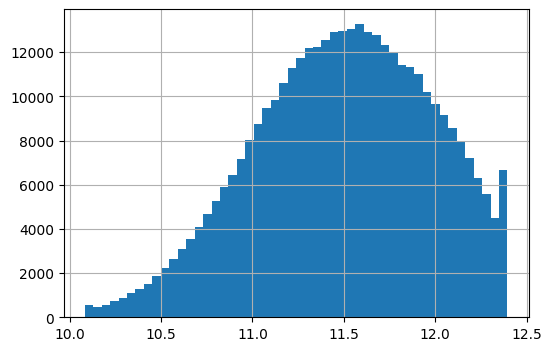

In [14]:
income = df['income_generated']


count = income.value_counts().sort_index()

log_income = np.log1p(income)

plt.figure(figsize=(6, 4))
plt.hist(log_income, bins=50)
plt.grid(True)
plt.show()

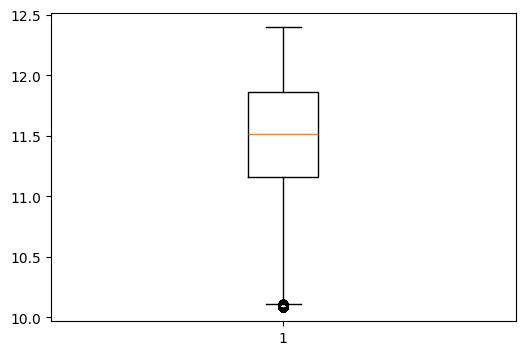

In [15]:
plt.figure(figsize=(6, 4))
plt.boxplot(log_income)
plt.show()

In [1]:
import os
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


# =========================
# CONFIG
# =========================

RAW_PATH = "raw/train_wide.csv"
OUTPUT_PATH = "processed/v1/train_wide_with_income_catboost.csv"
METRICS_PATH = "processed/v1/income_metrics_catboost.csv"

RANDOM_SEED = 52

TRAIN_INCOME_LOWER_QUANTILE = 0.005
TRAIN_INCOME_UPPER_QUANTILE = 0.90


# =========================
# FEATURE ENGINEERING
# =========================

def make_age_group(age):
    if pd.isna(age):
        return "UNKNOWN"
    if age < 18:
        return "UNDER_18"
    if age <= 24:
        return "18_24"
    if age <= 34:
        return "25_34"
    if age <= 44:
        return "35_44"
    if age <= 54:
        return "45_54"
    if age <= 64:
        return "55_64"
    return "65_PLUS"


def prepare_income_features(df):
    df = df.copy()

    df = df.dropna(subset=["sex"])
    df["sex"] = df["sex"].astype(str)

    df["segment"] = df["segment"].fillna("UNKNOWN").astype(str)

    df["seniority_months"] = pd.to_numeric(df["seniority_months"], errors="coerce")
    df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
    df = df.dropna(subset=["seniority_months"])
    df["seniority_months"] = df["seniority_months"].round().astype("float64")

    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[
        (df["age"] < 14) | (df["age"] > 95),
        "age"
    ] = np.nan
    df = df.dropna(subset=["age"])
    df["age"] = df["age"].round().astype("float64")

    df["age_group"] = df["age"].apply(make_age_group)

    df["is_new_customer"] = pd.to_numeric(
        df["is_new_customer"],
        errors="coerce"
    ).fillna(0).astype("float64")

    prefixes = ("dep-", "card-", "rko-", "loan-", "srv-", "biz-")

    product_cols = [
        col for col in df.columns
        if col.startswith(prefixes)
    ]

    for col in product_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float64")

    dep_cols = [col for col in product_cols if col.startswith("dep-")]
    card_cols = [col for col in product_cols if col.startswith("card-")]
    rko_cols = [col for col in product_cols if col.startswith("rko-")]
    loan_cols = [col for col in product_cols if col.startswith("loan-")]
    srv_cols = [col for col in product_cols if col.startswith("srv-")]
    biz_cols = [col for col in product_cols if col.startswith("biz-")]

    df["products_count"] = df[product_cols].sum(axis=1) if product_cols else 0.0

    df["dep_count"] = df[dep_cols].sum(axis=1) if dep_cols else 0.0
    df["card_count"] = df[card_cols].sum(axis=1) if card_cols else 0.0
    df["rko_count"] = df[rko_cols].sum(axis=1) if rko_cols else 0.0
    df["loan_count"] = df[loan_cols].sum(axis=1) if loan_cols else 0.0
    df["srv_count"] = df[srv_cols].sum(axis=1) if srv_cols else 0.0
    df["biz_count"] = df[biz_cols].sum(axis=1) if biz_cols else 0.0

    df["has_dep"] = (df["dep_count"] > 0).astype(int)
    df["has_card"] = (df["card_count"] > 0).astype(int)
    df["has_rko"] = (df["rko_count"] > 0).astype(int)
    df["has_loan"] = (df["loan_count"] > 0).astype(int)
    df["has_srv"] = (df["srv_count"] > 0).astype(int)
    df["has_biz"] = (df["biz_count"] > 0).astype(int)

    def product_profile(row):
        if row["products_count"] == 0:
            return "NO_PRODUCTS"

        profile = []

        if row["has_dep"]:
            profile.append("DEP")
        if row["has_card"]:
            profile.append("CARD")
        if row["has_rko"]:
            profile.append("RKO")
        if row["has_loan"]:
            profile.append("LOAN")
        if row["has_srv"]:
            profile.append("SRV")
        if row["has_biz"]:
            profile.append("BIZ")

        return "_".join(profile)

    df["product_profile"] = df.apply(product_profile, axis=1)

    return df, product_cols


# =========================
# TARGET MEDIAN FEATURES
# =========================

def add_group_median_features_fit_transform(train_df, target_col="income"):
    train_df = train_df.copy()

    global_median = train_df[target_col].median()

    group_specs = {
        "median_income_by_segment": ["segment"],
        "median_income_by_age_group": ["age_group"],
        "median_income_by_product_profile": ["product_profile"],
        "median_income_by_segment_age": ["segment", "age_group"],
        "median_income_by_segment_product": ["segment", "product_profile"],
        "median_income_by_age_product": ["age_group", "product_profile"],
    }

    median_maps = {}

    for feature_name, group_cols in group_specs.items():
        medians = train_df.groupby(group_cols)[target_col].median()
        median_maps[feature_name] = {
            "group_cols": group_cols,
            "medians": medians,
            "global_median": global_median
        }

        train_df[feature_name] = train_df[group_cols].apply(
            lambda row: medians.get(tuple(row), global_median)
            if len(group_cols) > 1
            else medians.get(row.iloc[0], global_median),
            axis=1
        ).astype("float64")

    return train_df, median_maps


def add_group_median_features_transform(df, median_maps):
    df = df.copy()

    for feature_name, info in median_maps.items():
        group_cols = info["group_cols"]
        medians = info["medians"]
        global_median = info["global_median"]

        df[feature_name] = df[group_cols].apply(
            lambda row: medians.get(tuple(row), global_median)
            if len(group_cols) > 1
            else medians.get(row.iloc[0], global_median),
            axis=1
        ).astype("float64")

    return df


# =========================
# METRICS
# =========================

def calculate_metrics(y_true, y_pred, title):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    medae = median_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmsle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {title} ===")
    print(f"Rows: {len(y_true):,}")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MedianAE: {medae:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R2: {r2:.4f}")

    return {
        "title": title,
        "rows": len(y_true),
        "mae": mae,
        "rmse": rmse,
        "median_ae": medae,
        "mape": mape,
        "rmsle": rmsle,
        "r2": r2
    }


# =========================
# LOAD DATA
# =========================

df = pd.read_csv(RAW_PATH)
original_cols = df.columns.tolist()

print("Original rows:", len(df))

df, product_cols = prepare_income_features(df)

print("Rows after feature cleaning:", len(df))
print("Product columns:", product_cols)

known_mask = df["income"].notna() & (df["income"] > 0)
known_df_raw = df.loc[known_mask].copy()

lower = known_df_raw["income"].quantile(TRAIN_INCOME_LOWER_QUANTILE)
upper = known_df_raw["income"].quantile(TRAIN_INCOME_UPPER_QUANTILE)

known_df = known_df_raw[
    (known_df_raw["income"] >= lower) &
    (known_df_raw["income"] <= upper)
].copy()

print("\nIncome cut:")
print(f"Lower q{TRAIN_INCOME_LOWER_QUANTILE}: {lower:,.2f}")
print(f"Upper q{TRAIN_INCOME_UPPER_QUANTILE}: {upper:,.2f}")
print("Known rows before cut:", len(known_df_raw))
print("Known rows after cut:", len(known_df))
print("Removed rows:", len(known_df_raw) - len(known_df_raw[
    (known_df_raw["income"] >= lower) &
    (known_df_raw["income"] <= upper)
]))

known_df = known_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


# =========================
# SPLIT
# =========================

cat_features = [
    "sex",
    "segment",
    "age_group",
    "product_profile"
]

base_num_features = [
    "age",
    "is_new_customer",
    "seniority_months",
    "products_count",
    "dep_count",
    "card_count",
    "rko_count",
    "loan_count",
    "srv_count",
    "biz_count",
    "has_dep",
    "has_card",
    "has_rko",
    "has_loan",
    "has_srv",
    "has_biz"
] + product_cols

segment_counts = known_df["segment"].value_counts()
stratify_col = known_df["segment"] if segment_counts.min() >= 2 else None

train_df, test_df = train_test_split(
    known_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=stratify_col
)

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))


# =========================
# ADD MEDIAN FEATURES WITHOUT TEST LEAKAGE
# =========================

train_df, median_maps = add_group_median_features_fit_transform(
    train_df,
    target_col="income"
)

test_df = add_group_median_features_transform(test_df, median_maps)
df_with_medians = add_group_median_features_transform(df, median_maps)

median_features = list(median_maps.keys())

num_features = base_num_features + median_features

features = cat_features + num_features

for col in cat_features:
    train_df[col] = train_df[col].fillna("UNKNOWN").astype(str)
    test_df[col] = test_df[col].fillna("UNKNOWN").astype(str)
    df_with_medians[col] = df_with_medians[col].fillna("UNKNOWN").astype(str)

for col in num_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce").fillna(0).astype("float64")
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce").fillna(0).astype("float64")
    df_with_medians[col] = pd.to_numeric(df_with_medians[col], errors="coerce").fillna(0).astype("float64")

X_train = train_df[features]
y_train = train_df["income"]

X_test = test_df[features]
y_test = test_df["income"]

X_all = df_with_medians[features]


# =========================
# CATBOOST MODEL
# =========================

catboost_model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=1200,
    learning_rate=0.04,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False
)

print("\nCat features:", cat_features)
print("Median features:", median_features)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)


# =========================
# METRICS
# =========================

train_pred = catboost_model.predict(X_train)
test_pred = catboost_model.predict(X_test)

train_pred = np.clip(train_pred, lower, upper)
test_pred = np.clip(test_pred, lower, upper)

train_metrics = calculate_metrics(
    y_true=y_train,
    y_pred=train_pred,
    title="CatBoost MAE + group medians on train"
)

test_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=test_pred,
    title="CatBoost MAE + group medians on test"
)

metrics_df = pd.DataFrame({
    "catboost_train": train_metrics,
    "catboost_test": test_metrics
}).T

print("\nMetrics summary:")
display(metrics_df)


# =========================
# GENERATE INCOME FOR FULL DATASET
# =========================

pred_all = catboost_model.predict(X_all)
pred_all = np.clip(pred_all, lower, upper)

df_with_medians["income_model_prediction"] = np.round(pred_all, 2)

missing_mask = df_with_medians["income"].isna() | (df_with_medians["income"] <= 0)

df_with_medians["income_generated"] = np.nan
df_with_medians.loc[missing_mask, "income_generated"] = df_with_medians.loc[
    missing_mask,
    "income_model_prediction"
]

df_with_medians["income_filled"] = df_with_medians["income"]
df_with_medians.loc[missing_mask, "income_filled"] = df_with_medians.loc[
    missing_mask,
    "income_generated"
]

df_with_medians["income_was_generated"] = missing_mask.astype(int)


# =========================
# SAVE
# =========================

extra_cols = [
    "income_model_prediction",
    "income_generated",
    "income_filled",
    "income_was_generated"
]

output_cols = []

for col in original_cols:
    if col in df_with_medians.columns:
        output_cols.append(col)

for col in extra_cols:
    if col in df_with_medians.columns and col not in output_cols:
        output_cols.append(col)

df_out = df_with_medians[output_cols].copy()

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_out.to_csv(OUTPUT_PATH, index=False)
metrics_df.to_csv(METRICS_PATH, index=True)

print("\nSaved dataset:")
print(OUTPUT_PATH)

print("\nSaved metrics:")
print(METRICS_PATH)

print("\nGenerated income rows:", int(df_out["income_was_generated"].sum()))

Original rows: 376141
Rows after feature cleaning: 372501
Product columns: ['dep-7', 'card-2', 'dep-5', 'card-1', 'card-5', 'rko-2', 'rko-3', 'rko-4', 'dep-9', 'dep-1', 'dep-3', 'rko-1', 'dep-2', 'loan-2', 'card-4', 'loan-1', 'srv-3', 'loan-5', 'biz-4', 'dep-6', 'loan-4', 'card-3']

Income cut:
Lower q0.005: 23,917.68
Upper q0.9: 241,721.01
Known rows before cut: 288171
Known rows after cut: 257914
Removed rows: 30257

Train rows: 206331
Test rows: 51583

Cat features: ['sex', 'segment', 'age_group', 'product_profile']
Median features: ['median_income_by_segment', 'median_income_by_age_group', 'median_income_by_product_profile', 'median_income_by_segment_age', 'median_income_by_segment_product', 'median_income_by_age_product']
0:	learn: 40783.4671206	test: 40680.3598637	best: 40680.3598637 (0)	total: 215ms	remaining: 4m 17s
100:	learn: 39136.6257160	test: 39143.1733183	best: 39143.1733183 (100)	total: 4.78s	remaining: 52s
200:	learn: 39055.4352055	test: 39110.5234774	best: 39110.422461

,title,rows,mae,rmse,median_ae,mape,rmsle,r2
catboost_train,CatBoost MAE + group medians on train,206331,38814.985037,49129.912409,32299.118096,42.207991,0.463856,0.054792
catboost_test,CatBoost MAE + group medians on test,51583,39061.127252,49384.345134,32526.770645,42.366661,0.46518,0.041917



Saved dataset:
processed/v1/train_wide_with_income_catboost.csv

Saved metrics:
processed/v1/income_metrics_catboost.csv

Generated income rows: 84330


In [2]:
df = pd.read_csv("raw/train_wide.csv")
df.head()

,user_id,sex,age,is_new_customer,seniority_months,income,segment,dep-7,card-2,dep-5,...,dep-2,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3
0,657788,F,42,0.0,114,132559.35,INDIVIDUALS,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,657795,M,44,0.0,114,81399.57,INDIVIDUALS,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,657790,M,42,0.0,114,NaN,INDIVIDUALS,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,657794,F,49,0.0,114,102189.00,VIP,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,657789,M,36,0.0,91,153725.49,VIP,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [7]:
unique_users = df["user_id"].nunique()
total_rows = len(df)

print("Unique user_id:", unique_users)
print("Total rows:", total_rows)
print("Rows per user_id avg:", total_rows / unique_users)

Unique user_id: 376141
Total rows: 376141
Rows per user_id avg: 1.0


In [8]:
import os
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)


# =========================
# CONFIG
# =========================

RAW_PATH = "raw/train_wide.csv"
OUTPUT_PATH = "processed/v1/train_wide_with_income_two_stage.csv"
METRICS_PATH = "processed/v1/income_metrics_two_stage.csv"

RANDOM_SEED = 52

TRAIN_INCOME_LOWER_QUANTILE = 0.005
TRAIN_INCOME_UPPER_QUANTILE = 0.90

BUCKET_Q1 = 0.33
BUCKET_Q2 = 0.66


# =========================
# FEATURE ENGINEERING
# =========================

def make_age_group(age):
    if pd.isna(age):
        return "UNKNOWN"
    if age < 18:
        return "UNDER_18"
    if age <= 24:
        return "18_24"
    if age <= 34:
        return "25_34"
    if age <= 44:
        return "35_44"
    if age <= 54:
        return "45_54"
    if age <= 64:
        return "55_64"
    return "65_PLUS"


def prepare_income_features(df):
    df = df.copy()

    df = df.dropna(subset=["sex"])
    df["sex"] = df["sex"].astype(str)

    df["segment"] = df["segment"].fillna("UNKNOWN").astype(str)

    df["seniority_months"] = pd.to_numeric(df["seniority_months"], errors="coerce")
    df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
    df = df.dropna(subset=["seniority_months"])
    df["seniority_months"] = df["seniority_months"].round().astype("float64")

    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[
        (df["age"] < 14) | (df["age"] > 95),
        "age"
    ] = np.nan
    df = df.dropna(subset=["age"])
    df["age"] = df["age"].round().astype("float64")

    df["age_group"] = df["age"].apply(make_age_group)

    df["is_new_customer"] = pd.to_numeric(
        df["is_new_customer"],
        errors="coerce"
    ).fillna(0).astype("float64")

    prefixes = ("dep-", "card-", "rko-", "loan-", "srv-", "biz-")

    product_cols = [
        col for col in df.columns
        if col.startswith(prefixes)
    ]

    for col in product_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float64")

    dep_cols = [col for col in product_cols if col.startswith("dep-")]
    card_cols = [col for col in product_cols if col.startswith("card-")]
    rko_cols = [col for col in product_cols if col.startswith("rko-")]
    loan_cols = [col for col in product_cols if col.startswith("loan-")]
    srv_cols = [col for col in product_cols if col.startswith("srv-")]
    biz_cols = [col for col in product_cols if col.startswith("biz-")]

    df["products_count"] = df[product_cols].sum(axis=1) if product_cols else 0.0

    df["dep_count"] = df[dep_cols].sum(axis=1) if dep_cols else 0.0
    df["card_count"] = df[card_cols].sum(axis=1) if card_cols else 0.0
    df["rko_count"] = df[rko_cols].sum(axis=1) if rko_cols else 0.0
    df["loan_count"] = df[loan_cols].sum(axis=1) if loan_cols else 0.0
    df["srv_count"] = df[srv_cols].sum(axis=1) if srv_cols else 0.0
    df["biz_count"] = df[biz_cols].sum(axis=1) if biz_cols else 0.0

    df["has_dep"] = (df["dep_count"] > 0).astype(int)
    df["has_card"] = (df["card_count"] > 0).astype(int)
    df["has_rko"] = (df["rko_count"] > 0).astype(int)
    df["has_loan"] = (df["loan_count"] > 0).astype(int)
    df["has_srv"] = (df["srv_count"] > 0).astype(int)
    df["has_biz"] = (df["biz_count"] > 0).astype(int)

    def product_profile(row):
        if row["products_count"] == 0:
            return "NO_PRODUCTS"

        profile = []

        if row["has_dep"]:
            profile.append("DEP")
        if row["has_card"]:
            profile.append("CARD")
        if row["has_rko"]:
            profile.append("RKO")
        if row["has_loan"]:
            profile.append("LOAN")
        if row["has_srv"]:
            profile.append("SRV")
        if row["has_biz"]:
            profile.append("BIZ")

        return "_".join(profile)

    df["product_profile"] = df.apply(product_profile, axis=1)

    return df, product_cols


# =========================
# GROUP MEDIAN FEATURES
# =========================

def add_group_median_features_fit_transform(train_df, target_col="income"):
    train_df = train_df.copy()

    global_median = train_df[target_col].median()

    group_specs = {
        "median_income_by_segment": ["segment"],
        "median_income_by_age_group": ["age_group"],
        "median_income_by_product_profile": ["product_profile"],
        "median_income_by_segment_age": ["segment", "age_group"],
        "median_income_by_segment_product": ["segment", "product_profile"],
        "median_income_by_age_product": ["age_group", "product_profile"],
    }

    median_maps = {}

    for feature_name, group_cols in group_specs.items():
        medians = train_df.groupby(group_cols)[target_col].median()

        median_maps[feature_name] = {
            "group_cols": group_cols,
            "medians": medians,
            "global_median": global_median
        }

        def get_median(row):
            if len(group_cols) == 1:
                key = row[group_cols[0]]
            else:
                key = tuple(row[col] for col in group_cols)

            return medians.get(key, global_median)

        train_df[feature_name] = train_df.apply(get_median, axis=1).astype("float64")

    return train_df, median_maps


def add_group_median_features_transform(df, median_maps):
    df = df.copy()

    for feature_name, info in median_maps.items():
        group_cols = info["group_cols"]
        medians = info["medians"]
        global_median = info["global_median"]

        def get_median(row):
            if len(group_cols) == 1:
                key = row[group_cols[0]]
            else:
                key = tuple(row[col] for col in group_cols)

            return medians.get(key, global_median)

        df[feature_name] = df.apply(get_median, axis=1).astype("float64")

    return df


# =========================
# METRICS
# =========================

def calculate_metrics(y_true, y_pred, title):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    medae = median_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmsle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {title} ===")
    print(f"Rows: {len(y_true):,}")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MedianAE: {medae:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R2: {r2:.4f}")

    return {
        "title": title,
        "rows": len(y_true),
        "mae": mae,
        "rmse": rmse,
        "median_ae": medae,
        "mape": mape,
        "rmsle": rmsle,
        "r2": r2
    }


# =========================
# LOAD DATA
# =========================

df = pd.read_csv(RAW_PATH)
original_cols = df.columns.tolist()

print("Original rows:", len(df))

df, product_cols = prepare_income_features(df)

print("Rows after feature cleaning:", len(df))
print("Product columns:", product_cols)

known_mask = df["income"].notna() & (df["income"] > 0)
known_df_raw = df.loc[known_mask].copy()

lower = known_df_raw["income"].quantile(TRAIN_INCOME_LOWER_QUANTILE)
upper = known_df_raw["income"].quantile(TRAIN_INCOME_UPPER_QUANTILE)

known_df = known_df_raw[
    (known_df_raw["income"] >= lower) &
    (known_df_raw["income"] <= upper)
].copy()

print("\nIncome cut:")
print(f"Lower q{TRAIN_INCOME_LOWER_QUANTILE}: {lower:,.2f}")
print(f"Upper q{TRAIN_INCOME_UPPER_QUANTILE}: {upper:,.2f}")
print("Known rows before cut:", len(known_df_raw))
print("Known rows after cut:", len(known_df))
print("Removed rows:", len(known_df_raw) - len(known_df))

known_df = known_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


# =========================
# SPLIT
# =========================

segment_counts = known_df["segment"].value_counts()
stratify_col = known_df["segment"] if segment_counts.min() >= 2 else None

train_df, test_df = train_test_split(
    known_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=stratify_col
)

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))


# =========================
# INCOME BUCKETS
# =========================

q1 = train_df["income"].quantile(BUCKET_Q1)
q2 = train_df["income"].quantile(BUCKET_Q2)

print("\nIncome bucket thresholds:")
print(f"LOW <= {q1:,.2f}")
print(f"MID <= {q2:,.2f}")
print(f"HIGH > {q2:,.2f}")


def make_income_bucket(income):
    if income <= q1:
        return 0  # LOW
    if income <= q2:
        return 1  # MID
    return 2      # HIGH


bucket_names = {
    0: "LOW",
    1: "MID",
    2: "HIGH"
}

train_df["income_bucket"] = train_df["income"].apply(make_income_bucket)
test_df["income_bucket"] = test_df["income"].apply(make_income_bucket)

print("\nTrain bucket counts:")
print(train_df["income_bucket"].map(bucket_names).value_counts())

print("\nTest bucket counts:")
print(test_df["income_bucket"].map(bucket_names).value_counts())


# =========================
# MEDIAN FEATURES WITHOUT TEST LEAKAGE
# =========================

train_df, median_maps = add_group_median_features_fit_transform(
    train_df,
    target_col="income"
)

test_df = add_group_median_features_transform(test_df, median_maps)
df_with_medians = add_group_median_features_transform(df, median_maps)

median_features = list(median_maps.keys())


# =========================
# FEATURES
# =========================

cat_features = [
    "sex",
    "segment",
    "age_group",
    "product_profile"
]

base_num_features = [
    "age",
    "is_new_customer",
    "seniority_months",
    "products_count",
    "dep_count",
    "card_count",
    "rko_count",
    "loan_count",
    "srv_count",
    "biz_count",
    "has_dep",
    "has_card",
    "has_rko",
    "has_loan",
    "has_srv",
    "has_biz"
] + product_cols

num_features = base_num_features + median_features

features = cat_features + num_features

for col in cat_features:
    train_df[col] = train_df[col].fillna("UNKNOWN").astype(str)
    test_df[col] = test_df[col].fillna("UNKNOWN").astype(str)
    df_with_medians[col] = df_with_medians[col].fillna("UNKNOWN").astype(str)

for col in num_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce").fillna(0).astype("float64")
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce").fillna(0).astype("float64")
    df_with_medians[col] = pd.to_numeric(df_with_medians[col], errors="coerce").fillna(0).astype("float64")

X_train = train_df[features]
y_train = train_df["income"]

X_test = test_df[features]
y_test = test_df["income"]

X_all = df_with_medians[features]


# =========================
# STAGE 1: BUCKET CLASSIFIER
# =========================

bucket_clf = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="Accuracy",
    iterations=800,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False
)

bucket_clf.fit(
    X_train,
    train_df["income_bucket"],
    cat_features=cat_features,
    eval_set=(X_test, test_df["income_bucket"]),
    use_best_model=True
)

test_bucket_pred = bucket_clf.predict(X_test).astype(int).reshape(-1)

print("\n=== Bucket classification ===")
print("Accuracy:", accuracy_score(test_df["income_bucket"], test_bucket_pred))
print("\nClassification report:")
print(classification_report(
    test_df["income_bucket"],
    test_bucket_pred,
    target_names=["LOW", "MID", "HIGH"]
))

print("\nConfusion matrix:")
print(confusion_matrix(test_df["income_bucket"], test_bucket_pred))


# =========================
# STAGE 2: REGRESSOR PER BUCKET
# =========================

bucket_models = {}
bucket_medians = {}

for bucket_id in [0, 1, 2]:
    bucket_train = train_df[train_df["income_bucket"] == bucket_id].copy()

    bucket_median = bucket_train["income"].median()
    bucket_medians[bucket_id] = bucket_median

    print(f"\nTraining regressor for bucket {bucket_names[bucket_id]}")
    print("Rows:", len(bucket_train))
    print("Median income:", f"{bucket_median:,.2f}")

    if len(bucket_train) < 500:
        print("Too few rows, using median fallback only.")
        bucket_models[bucket_id] = None
        continue

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=1000,
        learning_rate=0.04,
        depth=6,
        l2_leaf_reg=5,
        random_seed=RANDOM_SEED,
        verbose=100,
        allow_writing_files=False
    )

    model.fit(
        bucket_train[features],
        bucket_train["income"],
        cat_features=cat_features
    )

    bucket_models[bucket_id] = model


# =========================
# TWO-STAGE PREDICTION ON TEST
# =========================

two_stage_pred = np.zeros(len(test_df))

for bucket_id in [0, 1, 2]:
    mask = test_bucket_pred == bucket_id

    if mask.sum() == 0:
        continue

    model = bucket_models[bucket_id]

    if model is None:
        two_stage_pred[mask] = bucket_medians[bucket_id]
    else:
        two_stage_pred[mask] = model.predict(X_test.loc[mask])

two_stage_pred = np.clip(two_stage_pred, lower, upper)


# =========================
# ORACLE BUCKET PREDICTION
# =========================
# Это не честная модель, но показывает верхний предел:
# насколько хорошо было бы, если бы классификатор бакетов не ошибался.

oracle_pred = np.zeros(len(test_df))
true_test_buckets = test_df["income_bucket"].values

for bucket_id in [0, 1, 2]:
    mask = true_test_buckets == bucket_id

    if mask.sum() == 0:
        continue

    model = bucket_models[bucket_id]

    if model is None:
        oracle_pred[mask] = bucket_medians[bucket_id]
    else:
        oracle_pred[mask] = model.predict(X_test.loc[mask])

oracle_pred = np.clip(oracle_pred, lower, upper)


# =========================
# SINGLE-STAGE BASELINE CATBOOST
# =========================

single_model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=1200,
    learning_rate=0.04,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False
)

single_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

single_pred = single_model.predict(X_test)
single_pred = np.clip(single_pred, lower, upper)


# =========================
# METRICS
# =========================

two_stage_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=two_stage_pred,
    title="TWO-STAGE CatBoost on test"
)

oracle_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=oracle_pred,
    title="ORACLE bucket CatBoost on test"
)

single_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=single_pred,
    title="SINGLE-STAGE CatBoost on test"
)

metrics_df = pd.DataFrame({
    "two_stage_test": two_stage_metrics,
    "oracle_bucket_test": oracle_metrics,
    "single_stage_test": single_metrics
}).T

print("\nMetrics summary:")
display(metrics_df)


# =========================
# GENERATE INCOME FOR FULL DATASET
# =========================

all_bucket_pred = bucket_clf.predict(X_all).astype(int).reshape(-1)

pred_all = np.zeros(len(df_with_medians))

for bucket_id in [0, 1, 2]:
    mask = all_bucket_pred == bucket_id

    if mask.sum() == 0:
        continue

    model = bucket_models[bucket_id]

    if model is None:
        pred_all[mask] = bucket_medians[bucket_id]
    else:
        pred_all[mask] = model.predict(X_all.loc[mask])

pred_all = np.clip(pred_all, lower, upper)

df_with_medians["income_model_prediction"] = np.round(pred_all, 2)

missing_mask = df_with_medians["income"].isna() | (df_with_medians["income"] <= 0)

df_with_medians["income_generated"] = np.nan
df_with_medians.loc[missing_mask, "income_generated"] = df_with_medians.loc[
    missing_mask,
    "income_model_prediction"
]

df_with_medians["income_filled"] = df_with_medians["income"]
df_with_medians.loc[missing_mask, "income_filled"] = df_with_medians.loc[
    missing_mask,
    "income_generated"
]

df_with_medians["income_was_generated"] = missing_mask.astype(int)


# =========================
# SAVE
# =========================

extra_cols = [
    "income_model_prediction",
    "income_generated",
    "income_filled",
    "income_was_generated"
]

output_cols = []

for col in original_cols:
    if col in df_with_medians.columns:
        output_cols.append(col)

for col in extra_cols:
    if col in df_with_medians.columns and col not in output_cols:
        output_cols.append(col)

df_out = df_with_medians[output_cols].copy()

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_out.to_csv(OUTPUT_PATH, index=False)
metrics_df.to_csv(METRICS_PATH, index=True)

print("\nSaved dataset:")
print(OUTPUT_PATH)

print("\nSaved metrics:")
print(METRICS_PATH)

print("\nGenerated income rows:", int(df_out["income_was_generated"].sum()))

Original rows: 376141
Rows after feature cleaning: 372501
Product columns: ['dep-7', 'card-2', 'dep-5', 'card-1', 'card-5', 'rko-2', 'rko-3', 'rko-4', 'dep-9', 'dep-1', 'dep-3', 'rko-1', 'dep-2', 'loan-2', 'card-4', 'loan-1', 'srv-3', 'loan-5', 'biz-4', 'dep-6', 'loan-4', 'card-3']

Income cut:
Lower q0.005: 23,917.68
Upper q0.9: 241,721.01
Known rows before cut: 288171
Known rows after cut: 257914
Removed rows: 30257

Train rows: 206331
Test rows: 51583

Income bucket thresholds:
LOW <= 79,587.75
MID <= 125,183.55
HIGH > 125,183.55

Train bucket counts:
income_bucket
HIGH    70148
MID     68093
LOW     68090
Name: count, dtype: int64

Test bucket counts:
income_bucket
HIGH    17483
MID     17140
LOW     16960
Name: count, dtype: int64
0:	learn: 0.4189530	test: 0.4155827	best: 0.4155827 (0)	total: 93.2ms	remaining: 1m 14s
100:	learn: 0.4245896	test: 0.4214179	best: 0.4218832 (47)	total: 8.52s	remaining: 59s
200:	learn: 0.4261066	test: 0.4221934	best: 0.4224454 (169)	total: 17s	remainin

,title,rows,mae,rmse,median_ae,mape,rmsle,r2
two_stage_test,TWO-STAGE CatBoost on test,51583,49985.813966,62655.183999,42250.517227,56.170042,0.598632,-0.542192
oracle_bucket_test,ORACLE bucket CatBoost on test,51583,16428.864009,21686.778148,13293.734538,16.538518,0.200102,0.815237
single_stage_test,SINGLE-STAGE CatBoost on test,51583,39061.127252,49384.345134,32526.770645,42.366661,0.46518,0.041917



Saved dataset:
processed/v1/train_wide_with_income_two_stage.csv

Saved metrics:
processed/v1/income_metrics_two_stage.csv

Generated income rows: 84330


In [9]:
import os
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)


# =========================
# CONFIG
# =========================

RAW_PATH = "raw/train_wide.csv"
OUTPUT_PATH = "processed/v1/train_wide_with_income_soft_mixture.csv"
METRICS_PATH = "processed/v1/income_metrics_soft_mixture.csv"

RANDOM_SEED = 52

TRAIN_INCOME_LOWER_QUANTILE = 0.005
TRAIN_INCOME_UPPER_QUANTILE = 0.90

BUCKET_Q1 = 0.33
BUCKET_Q2 = 0.66


# =========================
# FEATURE ENGINEERING
# =========================

def make_age_group(age):
    if pd.isna(age):
        return "UNKNOWN"
    if age < 18:
        return "UNDER_18"
    if age <= 24:
        return "18_24"
    if age <= 34:
        return "25_34"
    if age <= 44:
        return "35_44"
    if age <= 54:
        return "45_54"
    if age <= 64:
        return "55_64"
    return "65_PLUS"


def prepare_income_features(df):
    df = df.copy()

    df = df.dropna(subset=["sex"])
    df["sex"] = df["sex"].astype(str)

    df["segment"] = df["segment"].fillna("UNKNOWN").astype(str)

    df["seniority_months"] = pd.to_numeric(df["seniority_months"], errors="coerce")
    df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
    df = df.dropna(subset=["seniority_months"])
    df["seniority_months"] = df["seniority_months"].round().astype("float64")

    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[(df["age"] < 14) | (df["age"] > 95), "age"] = np.nan
    df = df.dropna(subset=["age"])
    df["age"] = df["age"].round().astype("float64")

    df["age_group"] = df["age"].apply(make_age_group)

    df["is_new_customer"] = pd.to_numeric(
        df["is_new_customer"],
        errors="coerce"
    ).fillna(0).astype("float64")

    prefixes = ("dep-", "card-", "rko-", "loan-", "srv-", "biz-")

    product_cols = [
        col for col in df.columns
        if col.startswith(prefixes)
    ]

    for col in product_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float64")

    dep_cols = [col for col in product_cols if col.startswith("dep-")]
    card_cols = [col for col in product_cols if col.startswith("card-")]
    rko_cols = [col for col in product_cols if col.startswith("rko-")]
    loan_cols = [col for col in product_cols if col.startswith("loan-")]
    srv_cols = [col for col in product_cols if col.startswith("srv-")]
    biz_cols = [col for col in product_cols if col.startswith("biz-")]

    df["products_count"] = df[product_cols].sum(axis=1) if product_cols else 0.0

    df["dep_count"] = df[dep_cols].sum(axis=1) if dep_cols else 0.0
    df["card_count"] = df[card_cols].sum(axis=1) if card_cols else 0.0
    df["rko_count"] = df[rko_cols].sum(axis=1) if rko_cols else 0.0
    df["loan_count"] = df[loan_cols].sum(axis=1) if loan_cols else 0.0
    df["srv_count"] = df[srv_cols].sum(axis=1) if srv_cols else 0.0
    df["biz_count"] = df[biz_cols].sum(axis=1) if biz_cols else 0.0

    df["has_dep"] = (df["dep_count"] > 0).astype(int)
    df["has_card"] = (df["card_count"] > 0).astype(int)
    df["has_rko"] = (df["rko_count"] > 0).astype(int)
    df["has_loan"] = (df["loan_count"] > 0).astype(int)
    df["has_srv"] = (df["srv_count"] > 0).astype(int)
    df["has_biz"] = (df["biz_count"] > 0).astype(int)

    def product_profile(row):
        if row["products_count"] == 0:
            return "NO_PRODUCTS"

        profile = []

        if row["has_dep"]:
            profile.append("DEP")
        if row["has_card"]:
            profile.append("CARD")
        if row["has_rko"]:
            profile.append("RKO")
        if row["has_loan"]:
            profile.append("LOAN")
        if row["has_srv"]:
            profile.append("SRV")
        if row["has_biz"]:
            profile.append("BIZ")

        return "_".join(profile)

    df["product_profile"] = df.apply(product_profile, axis=1)

    return df, product_cols


# =========================
# MEDIAN FEATURES WITHOUT TEST LEAKAGE
# =========================

def add_group_median_features_fit_transform(train_df, target_col="income"):
    train_df = train_df.copy()

    global_median = train_df[target_col].median()

    group_specs = {
        "median_income_by_segment": ["segment"],
        "median_income_by_age_group": ["age_group"],
        "median_income_by_product_profile": ["product_profile"],
        "median_income_by_segment_age": ["segment", "age_group"],
        "median_income_by_segment_product": ["segment", "product_profile"],
        "median_income_by_age_product": ["age_group", "product_profile"],
    }

    median_maps = {}

    for feature_name, group_cols in group_specs.items():
        medians = train_df.groupby(group_cols)[target_col].median()

        median_maps[feature_name] = {
            "group_cols": group_cols,
            "medians": medians,
            "global_median": global_median
        }

        def get_median(row):
            if len(group_cols) == 1:
                key = row[group_cols[0]]
            else:
                key = tuple(row[col] for col in group_cols)

            return medians.get(key, global_median)

        train_df[feature_name] = train_df.apply(get_median, axis=1).astype("float64")

    return train_df, median_maps


def add_group_median_features_transform(df, median_maps):
    df = df.copy()

    for feature_name, info in median_maps.items():
        group_cols = info["group_cols"]
        medians = info["medians"]
        global_median = info["global_median"]

        def get_median(row):
            if len(group_cols) == 1:
                key = row[group_cols[0]]
            else:
                key = tuple(row[col] for col in group_cols)

            return medians.get(key, global_median)

        df[feature_name] = df.apply(get_median, axis=1).astype("float64")

    return df


# =========================
# METRICS
# =========================

def calculate_metrics(y_true, y_pred, title):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    medae = median_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmsle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {title} ===")
    print(f"Rows: {len(y_true):,}")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MedianAE: {medae:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R2: {r2:.4f}")

    return {
        "title": title,
        "rows": len(y_true),
        "mae": mae,
        "rmse": rmse,
        "median_ae": medae,
        "mape": mape,
        "rmsle": rmsle,
        "r2": r2
    }


# =========================
# LOAD DATA
# =========================

df = pd.read_csv(RAW_PATH)
original_cols = df.columns.tolist()

print("Original rows:", len(df))

df, product_cols = prepare_income_features(df)

print("Rows after feature cleaning:", len(df))
print("Product columns:", product_cols)

known_mask = df["income"].notna() & (df["income"] > 0)
known_df_raw = df.loc[known_mask].copy()

lower = known_df_raw["income"].quantile(TRAIN_INCOME_LOWER_QUANTILE)
upper = known_df_raw["income"].quantile(TRAIN_INCOME_UPPER_QUANTILE)

known_df = known_df_raw[
    (known_df_raw["income"] >= lower) &
    (known_df_raw["income"] <= upper)
].copy()

print("\nIncome cut:")
print(f"Lower q{TRAIN_INCOME_LOWER_QUANTILE}: {lower:,.2f}")
print(f"Upper q{TRAIN_INCOME_UPPER_QUANTILE}: {upper:,.2f}")
print("Known rows before cut:", len(known_df_raw))
print("Known rows after cut:", len(known_df))
print("Removed rows:", len(known_df_raw) - len(known_df))

known_df = known_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


# =========================
# SPLIT
# =========================

segment_counts = known_df["segment"].value_counts()
stratify_col = known_df["segment"] if segment_counts.min() >= 2 else None

train_df, test_df = train_test_split(
    known_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=stratify_col
)

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))


# =========================
# INCOME BUCKETS
# =========================

q1 = train_df["income"].quantile(BUCKET_Q1)
q2 = train_df["income"].quantile(BUCKET_Q2)

print("\nIncome bucket thresholds:")
print(f"LOW <= {q1:,.2f}")
print(f"MID <= {q2:,.2f}")
print(f"HIGH > {q2:,.2f}")


def make_income_bucket(income):
    if income <= q1:
        return 0
    if income <= q2:
        return 1
    return 2


bucket_names = {
    0: "LOW",
    1: "MID",
    2: "HIGH"
}

train_df["income_bucket"] = train_df["income"].apply(make_income_bucket)
test_df["income_bucket"] = test_df["income"].apply(make_income_bucket)

print("\nTrain bucket counts:")
print(train_df["income_bucket"].map(bucket_names).value_counts())

print("\nTest bucket counts:")
print(test_df["income_bucket"].map(bucket_names).value_counts())


# =========================
# MEDIAN FEATURES
# =========================

train_df, median_maps = add_group_median_features_fit_transform(
    train_df,
    target_col="income"
)

test_df = add_group_median_features_transform(test_df, median_maps)
df_with_medians = add_group_median_features_transform(df, median_maps)

median_features = list(median_maps.keys())


# =========================
# FEATURES
# =========================

cat_features = [
    "sex",
    "segment",
    "age_group",
    "product_profile"
]

base_num_features = [
    "age",
    "is_new_customer",
    "seniority_months",
    "products_count",
    "dep_count",
    "card_count",
    "rko_count",
    "loan_count",
    "srv_count",
    "biz_count",
    "has_dep",
    "has_card",
    "has_rko",
    "has_loan",
    "has_srv",
    "has_biz"
] + product_cols

num_features = base_num_features + median_features

features = cat_features + num_features

for col in cat_features:
    train_df[col] = train_df[col].fillna("UNKNOWN").astype(str)
    test_df[col] = test_df[col].fillna("UNKNOWN").astype(str)
    df_with_medians[col] = df_with_medians[col].fillna("UNKNOWN").astype(str)

for col in num_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce").fillna(0).astype("float64")
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce").fillna(0).astype("float64")
    df_with_medians[col] = pd.to_numeric(df_with_medians[col], errors="coerce").fillna(0).astype("float64")

X_train = train_df[features]
y_train = train_df["income"]

X_test = test_df[features]
y_test = test_df["income"]

X_all = df_with_medians[features]


# =========================
# STAGE 1: BUCKET CLASSIFIER
# =========================

bucket_clf = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="Accuracy",
    iterations=1000,
    learning_rate=0.04,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False
)

bucket_clf.fit(
    X_train,
    train_df["income_bucket"],
    cat_features=cat_features,
    eval_set=(X_test, test_df["income_bucket"]),
    use_best_model=True
)

test_bucket_proba_raw = bucket_clf.predict_proba(X_test)
test_bucket_hard_pred = bucket_clf.predict(X_test).astype(int).reshape(-1)

class_order = bucket_clf.classes_.astype(int)

print("\nClass order:", class_order)

print("\n=== Bucket classification ===")
print("Accuracy:", accuracy_score(test_df["income_bucket"], test_bucket_hard_pred))
print("\nClassification report:")
print(classification_report(
    test_df["income_bucket"],
    test_bucket_hard_pred,
    target_names=["LOW", "MID", "HIGH"]
))

print("\nConfusion matrix:")
print(confusion_matrix(test_df["income_bucket"], test_bucket_hard_pred))


# =========================
# STAGE 2: REGRESSOR PER BUCKET
# =========================

bucket_models = {}
bucket_medians = {}

for bucket_id in [0, 1, 2]:
    bucket_train = train_df[train_df["income_bucket"] == bucket_id].copy()

    bucket_median = bucket_train["income"].median()
    bucket_medians[bucket_id] = bucket_median

    print(f"\nTraining regressor for bucket {bucket_names[bucket_id]}")
    print("Rows:", len(bucket_train))
    print("Median income:", f"{bucket_median:,.2f}")

    if len(bucket_train) < 500:
        print("Too few rows, using median fallback.")
        bucket_models[bucket_id] = None
        continue

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=1200,
        learning_rate=0.04,
        depth=6,
        l2_leaf_reg=5,
        random_seed=RANDOM_SEED,
        verbose=100,
        allow_writing_files=False
    )

    model.fit(
        bucket_train[features],
        bucket_train["income"],
        cat_features=cat_features
    )

    bucket_models[bucket_id] = model


# =========================
# HELPER: PREDICT ALL BUCKET REGRESSORS
# =========================

def predict_all_bucket_regressors(X):
    pred_matrix = np.zeros((len(X), 3))

    for bucket_id in [0, 1, 2]:
        model = bucket_models[bucket_id]

        if model is None:
            pred_matrix[:, bucket_id] = bucket_medians[bucket_id]
        else:
            pred_matrix[:, bucket_id] = model.predict(X)

    return pred_matrix


def align_proba_to_buckets(proba_raw, class_order):
    proba = np.zeros((proba_raw.shape[0], 3))

    for col_idx, class_id in enumerate(class_order):
        proba[:, int(class_id)] = proba_raw[:, col_idx]

    return proba


# =========================
# SOFT MIXTURE PREDICTION ON TEST
# =========================

test_regressor_preds = predict_all_bucket_regressors(X_test)
test_bucket_proba = align_proba_to_buckets(test_bucket_proba_raw, class_order)

soft_mixture_pred = (
    test_bucket_proba[:, 0] * test_regressor_preds[:, 0] +
    test_bucket_proba[:, 1] * test_regressor_preds[:, 1] +
    test_bucket_proba[:, 2] * test_regressor_preds[:, 2]
)

soft_mixture_pred = np.clip(soft_mixture_pred, lower, upper)


# =========================
# HARD TWO-STAGE PREDICTION ON TEST
# =========================

hard_two_stage_pred = np.zeros(len(X_test))

for bucket_id in [0, 1, 2]:
    mask = test_bucket_hard_pred == bucket_id

    if mask.sum() == 0:
        continue

    hard_two_stage_pred[mask] = test_regressor_preds[mask, bucket_id]

hard_two_stage_pred = np.clip(hard_two_stage_pred, lower, upper)


# =========================
# ORACLE BUCKET PREDICTION
# =========================

oracle_pred = np.zeros(len(X_test))
true_buckets = test_df["income_bucket"].values

for bucket_id in [0, 1, 2]:
    mask = true_buckets == bucket_id

    if mask.sum() == 0:
        continue

    oracle_pred[mask] = test_regressor_preds[mask, bucket_id]

oracle_pred = np.clip(oracle_pred, lower, upper)


# =========================
# SINGLE-STAGE BASELINE CATBOOST
# =========================

single_model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=1200,
    learning_rate=0.04,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False
)

single_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

single_pred = single_model.predict(X_test)
single_pred = np.clip(single_pred, lower, upper)


# =========================
# SIMPLE MEDIAN BASELINE
# =========================

global_median_pred = np.full(len(y_test), y_train.median())


# =========================
# METRICS
# =========================

soft_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=soft_mixture_pred,
    title="SOFT MIXTURE CatBoost on test"
)

hard_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=hard_two_stage_pred,
    title="HARD TWO-STAGE CatBoost on test"
)

oracle_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=oracle_pred,
    title="ORACLE bucket CatBoost on test"
)

single_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=single_pred,
    title="SINGLE-STAGE CatBoost on test"
)

median_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=global_median_pred,
    title="GLOBAL MEDIAN baseline on test"
)

metrics_df = pd.DataFrame({
    "soft_mixture_test": soft_metrics,
    "hard_two_stage_test": hard_metrics,
    "oracle_bucket_test": oracle_metrics,
    "single_stage_test": single_metrics,
    "global_median_test": median_metrics
}).T

print("\nMetrics summary:")
display(metrics_df)


# =========================
# GENERATE INCOME FOR FULL DATASET USING SOFT MIXTURE
# =========================

all_bucket_proba_raw = bucket_clf.predict_proba(X_all)
all_bucket_proba = align_proba_to_buckets(all_bucket_proba_raw, class_order)

all_regressor_preds = predict_all_bucket_regressors(X_all)

pred_all = (
    all_bucket_proba[:, 0] * all_regressor_preds[:, 0] +
    all_bucket_proba[:, 1] * all_regressor_preds[:, 1] +
    all_bucket_proba[:, 2] * all_regressor_preds[:, 2]
)

pred_all = np.clip(pred_all, lower, upper)

df_with_medians["income_model_prediction"] = np.round(pred_all, 2)

missing_mask = df_with_medians["income"].isna() | (df_with_medians["income"] <= 0)

df_with_medians["income_generated"] = np.nan
df_with_medians.loc[missing_mask, "income_generated"] = df_with_medians.loc[
    missing_mask,
    "income_model_prediction"
]

df_with_medians["income_filled"] = df_with_medians["income"]
df_with_medians.loc[missing_mask, "income_filled"] = df_with_medians.loc[
    missing_mask,
    "income_generated"
]

df_with_medians["income_was_generated"] = missing_mask.astype(int)


# =========================
# SAVE
# =========================

extra_cols = [
    "income_model_prediction",
    "income_generated",
    "income_filled",
    "income_was_generated"
]

output_cols = []

for col in original_cols:
    if col in df_with_medians.columns:
        output_cols.append(col)

for col in extra_cols:
    if col in df_with_medians.columns and col not in output_cols:
        output_cols.append(col)

df_out = df_with_medians[output_cols].copy()

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_out.to_csv(OUTPUT_PATH, index=False)
metrics_df.to_csv(METRICS_PATH, index=True)

print("\nSaved dataset:")
print(OUTPUT_PATH)

print("\nSaved metrics:")
print(METRICS_PATH)

print("\nGenerated income rows:", int(df_out["income_was_generated"].sum()))

Original rows: 376141
Rows after feature cleaning: 372501
Product columns: ['dep-7', 'card-2', 'dep-5', 'card-1', 'card-5', 'rko-2', 'rko-3', 'rko-4', 'dep-9', 'dep-1', 'dep-3', 'rko-1', 'dep-2', 'loan-2', 'card-4', 'loan-1', 'srv-3', 'loan-5', 'biz-4', 'dep-6', 'loan-4', 'card-3']

Income cut:
Lower q0.005: 23,917.68
Upper q0.9: 241,721.01
Known rows before cut: 288171
Known rows after cut: 257914
Removed rows: 30257

Train rows: 206331
Test rows: 51583

Income bucket thresholds:
LOW <= 79,587.75
MID <= 125,183.55
HIGH > 125,183.55

Train bucket counts:
income_bucket
HIGH    70148
MID     68093
LOW     68090
Name: count, dtype: int64

Test bucket counts:
income_bucket
HIGH    17483
MID     17140
LOW     16960
Name: count, dtype: int64
0:	learn: 0.4189530	test: 0.4155827	best: 0.4155827 (0)	total: 91.4ms	remaining: 1m 31s
100:	learn: 0.4247883	test: 0.4214955	best: 0.4219413 (91)	total: 9.36s	remaining: 1m 23s
200:	learn: 0.4258110	test: 0.4219413	best: 0.4221740 (129)	total: 18.4s	rem

,title,rows,mae,rmse,median_ae,mape,rmsle,r2
soft_mixture_test,SOFT MIXTURE CatBoost on test,51583,39466.596094,48707.567364,34497.268373,45.66487,0.472646,0.067997
hard_two_stage_test,HARD TWO-STAGE CatBoost on test,51583,50348.256548,62986.368671,42800.404953,56.92886,0.602,-0.558538
oracle_bucket_test,ORACLE bucket CatBoost on test,51583,16432.08997,21690.967264,13292.821833,16.541376,0.200139,0.815166
single_stage_test,SINGLE-STAGE CatBoost on test,51583,39061.127252,49384.345134,32526.770645,42.366661,0.46518,0.041917
global_median_test,GLOBAL MEDIAN baseline on test,51583,40792.885699,51337.601949,34264.68,44.285117,0.4816,-0.03537



Saved dataset:
processed/v1/train_wide_with_income_soft_mixture.csv

Saved metrics:
processed/v1/income_metrics_soft_mixture.csv

Generated income rows: 84330


In [10]:
import os
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


# =========================
# CONFIG
# =========================

RAW_PATH = "raw/train_wide_full.csv"
OUTPUT_PATH = "processed/v1/train_wide_with_income_extended_catboost.csv"
METRICS_PATH = "processed/v1/income_metrics_extended_catboost.csv"

RANDOM_SEED = 52

TRAIN_INCOME_LOWER_QUANTILE = 0.005
TRAIN_INCOME_UPPER_QUANTILE = 0.90


# =========================
# BASIC HELPERS
# =========================

def make_age_group(age):
    if pd.isna(age):
        return "UNKNOWN"
    if age < 18:
        return "UNDER_18"
    if age <= 24:
        return "18_24"
    if age <= 34:
        return "25_34"
    if age <= 44:
        return "35_44"
    if age <= 54:
        return "45_54"
    if age <= 64:
        return "55_64"
    return "65_PLUS"


def safe_category(df, col, default="UNKNOWN"):
    if col in df.columns:
        df[col] = df[col].fillna(default).astype(str)
    else:
        df[col] = default
    return df


def safe_numeric(df, col, default=0.0):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(default).astype("float64")
    else:
        df[col] = float(default)
    return df


# =========================
# FEATURE ENGINEERING
# =========================

def prepare_extended_income_features(df):
    df = df.copy()

    # -------------------------
    # Base columns
    # -------------------------

    df = df.dropna(subset=["sex"])
    df["sex"] = df["sex"].astype(str)

    df = safe_category(df, "segment")

    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[(df["age"] < 14) | (df["age"] > 95), "age"] = np.nan
    df = df.dropna(subset=["age"])
    df["age"] = df["age"].round().astype("float64")
    df["age_group"] = df["age"].apply(make_age_group)

    df["seniority_months"] = pd.to_numeric(df["seniority_months"], errors="coerce")
    df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
    df = df.dropna(subset=["seniority_months"])
    df["seniority_months"] = df["seniority_months"].round().astype("float64")

    df["seniority_years"] = df["seniority_months"] / 12

    df = safe_numeric(df, "is_new_customer", default=0.0)

    # -------------------------
    # Extended categorical columns
    # -------------------------

    extended_cat_cols = [
        "ind_empleado",
        "pais_residencia",
        "indrel",
        "indrel_1mes",
        "tiprel_1mes",
        "indresi",
        "indext",
        "conyuemp",
        "canal_entrada",
        "indfall",
        "tipodom",
        "cod_prov",
        "nomprov",
        "ind_actividad_cliente"
    ]

    for col in extended_cat_cols:
        df = safe_category(df, col)

    # -------------------------
    # Date features
    # -------------------------

    if "fecha_dato" in df.columns:
        fecha_dato = pd.to_datetime(df["fecha_dato"], errors="coerce")
        df["fecha_dato_year"] = fecha_dato.dt.year.fillna(0).astype("float64")
        df["fecha_dato_month"] = fecha_dato.dt.month.fillna(0).astype("float64")
    else:
        fecha_dato = None
        df["fecha_dato_year"] = 0.0
        df["fecha_dato_month"] = 0.0

    if "fecha_alta" in df.columns:
        fecha_alta = pd.to_datetime(df["fecha_alta"], errors="coerce")
        df["fecha_alta_year"] = fecha_alta.dt.year.fillna(0).astype("float64")
        df["fecha_alta_month"] = fecha_alta.dt.month.fillna(0).astype("float64")

        if fecha_dato is not None:
            client_age_days = (fecha_dato - fecha_alta).dt.days
            df["client_age_days_from_dates"] = (
                client_age_days.fillna(0).clip(lower=0).astype("float64")
            )
            df["client_age_months_from_dates"] = df["client_age_days_from_dates"] / 30.4375
        else:
            df["client_age_days_from_dates"] = 0.0
            df["client_age_months_from_dates"] = 0.0
    else:
        df["fecha_alta_year"] = 0.0
        df["fecha_alta_month"] = 0.0
        df["client_age_days_from_dates"] = 0.0
        df["client_age_months_from_dates"] = 0.0

    if "ult_fec_cli_1t" in df.columns:
        ult_fec_cli_1t = pd.to_datetime(df["ult_fec_cli_1t"], errors="coerce")
        df["has_ult_fec_cli_1t"] = ult_fec_cli_1t.notna().astype("float64")
    else:
        df["has_ult_fec_cli_1t"] = 0.0

    # -------------------------
    # Product columns
    # -------------------------

    mapped_prefixes = ("dep-", "card-", "rko-", "loan-", "srv-", "biz-")

    mapped_product_cols = [
        col for col in df.columns
        if col.startswith(mapped_prefixes)
    ]

    # Старые Santander-продукты вида ind_*_ult1
    santander_product_cols = [
        col for col in df.columns
        if col.startswith("ind_") and col.endswith("_ult1")
    ]

    product_cols = sorted(set(mapped_product_cols + santander_product_cols))

    for col in product_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float64")

    dep_cols = [col for col in product_cols if col.startswith("dep-")]
    card_cols = [col for col in product_cols if col.startswith("card-")]
    rko_cols = [col for col in product_cols if col.startswith("rko-")]
    loan_cols = [col for col in product_cols if col.startswith("loan-")]
    srv_cols = [col for col in product_cols if col.startswith("srv-")]
    biz_cols = [col for col in product_cols if col.startswith("biz-")]
    old_product_cols = [
        col for col in product_cols
        if col.startswith("ind_") and col.endswith("_ult1")
    ]

    df["products_count"] = df[product_cols].sum(axis=1) if product_cols else 0.0

    df["dep_count"] = df[dep_cols].sum(axis=1) if dep_cols else 0.0
    df["card_count"] = df[card_cols].sum(axis=1) if card_cols else 0.0
    df["rko_count"] = df[rko_cols].sum(axis=1) if rko_cols else 0.0
    df["loan_count"] = df[loan_cols].sum(axis=1) if loan_cols else 0.0
    df["srv_count"] = df[srv_cols].sum(axis=1) if srv_cols else 0.0
    df["biz_count"] = df[biz_cols].sum(axis=1) if biz_cols else 0.0
    df["old_product_count"] = df[old_product_cols].sum(axis=1) if old_product_cols else 0.0

    df["has_dep"] = (df["dep_count"] > 0).astype(int)
    df["has_card"] = (df["card_count"] > 0).astype(int)
    df["has_rko"] = (df["rko_count"] > 0).astype(int)
    df["has_loan"] = (df["loan_count"] > 0).astype(int)
    df["has_srv"] = (df["srv_count"] > 0).astype(int)
    df["has_biz"] = (df["biz_count"] > 0).astype(int)
    df["has_old_product"] = (df["old_product_count"] > 0).astype(int)

    df["products_per_seniority_year"] = (
        df["products_count"] / (df["seniority_years"] + 1)
    )

    df["active_with_products"] = (
        (df["ind_actividad_cliente"].astype(str) == "1") &
        (df["products_count"] > 0)
    ).astype(int)

    def product_profile(row):
        if row["products_count"] == 0:
            return "NO_PRODUCTS"

        profile = []

        if row["has_dep"]:
            profile.append("DEP")
        if row["has_card"]:
            profile.append("CARD")
        if row["has_rko"]:
            profile.append("RKO")
        if row["has_loan"]:
            profile.append("LOAN")
        if row["has_srv"]:
            profile.append("SRV")
        if row["has_biz"]:
            profile.append("BIZ")
        if row["has_old_product"]:
            profile.append("OLD")

        return "_".join(profile)

    df["product_profile"] = df.apply(product_profile, axis=1)

    return df, product_cols


# =========================
# GROUP MEDIAN FEATURES
# =========================

def add_group_median_features_fit_transform(train_df, target_col="income"):
    train_df = train_df.copy()
    global_median = train_df[target_col].median()

    group_specs = {
        "median_income_by_segment": ["segment"],
        "median_income_by_age_group": ["age_group"],
        "median_income_by_product_profile": ["product_profile"],
        "median_income_by_segment_age": ["segment", "age_group"],
        "median_income_by_segment_product": ["segment", "product_profile"],
        "median_income_by_age_product": ["age_group", "product_profile"],
        "median_income_by_province": ["nomprov"],
        "median_income_by_channel": ["canal_entrada"],
        "median_income_by_activity": ["ind_actividad_cliente"],
        "median_income_by_province_segment": ["nomprov", "segment"],
        "median_income_by_channel_segment": ["canal_entrada", "segment"],
    }

    median_maps = {}

    for feature_name, group_cols in group_specs.items():
        medians = train_df.groupby(group_cols)[target_col].median()

        median_maps[feature_name] = {
            "group_cols": group_cols,
            "medians": medians,
            "global_median": global_median
        }

        def get_median(row):
            if len(group_cols) == 1:
                key = row[group_cols[0]]
            else:
                key = tuple(row[col] for col in group_cols)
            return medians.get(key, global_median)

        train_df[feature_name] = train_df.apply(get_median, axis=1).astype("float64")

    return train_df, median_maps


def add_group_median_features_transform(df, median_maps):
    df = df.copy()

    for feature_name, info in median_maps.items():
        group_cols = info["group_cols"]
        medians = info["medians"]
        global_median = info["global_median"]

        def get_median(row):
            if len(group_cols) == 1:
                key = row[group_cols[0]]
            else:
                key = tuple(row[col] for col in group_cols)
            return medians.get(key, global_median)

        df[feature_name] = df.apply(get_median, axis=1).astype("float64")

    return df


# =========================
# METRICS
# =========================

def calculate_metrics(y_true, y_pred, title):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    medae = median_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmsle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {title} ===")
    print(f"Rows: {len(y_true):,}")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MedianAE: {medae:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R2: {r2:.4f}")

    return {
        "title": title,
        "rows": len(y_true),
        "mae": mae,
        "rmse": rmse,
        "median_ae": medae,
        "mape": mape,
        "rmsle": rmsle,
        "r2": r2
    }


# =========================
# LOAD DATA
# =========================

df = pd.read_csv(RAW_PATH)
original_cols = df.columns.tolist()

print("Original rows:", len(df))
print("Original columns:", len(df.columns))

df, product_cols = prepare_extended_income_features(df)

print("Rows after feature preparation:", len(df))
print("Detected product columns:", len(product_cols))
print("Product columns:", product_cols)

known_mask = df["income"].notna() & (df["income"] > 0)
known_df_raw = df.loc[known_mask].copy()

lower = known_df_raw["income"].quantile(TRAIN_INCOME_LOWER_QUANTILE)
upper = known_df_raw["income"].quantile(TRAIN_INCOME_UPPER_QUANTILE)

known_df = known_df_raw[
    (known_df_raw["income"] >= lower) &
    (known_df_raw["income"] <= upper)
].copy()

print("\nIncome cut:")
print(f"Lower q{TRAIN_INCOME_LOWER_QUANTILE}: {lower:,.2f}")
print(f"Upper q{TRAIN_INCOME_UPPER_QUANTILE}: {upper:,.2f}")
print("Known rows before cut:", len(known_df_raw))
print("Known rows after cut:", len(known_df))
print("Removed rows:", len(known_df_raw) - len(known_df))

known_df = known_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


# =========================
# SPLIT
# =========================

segment_counts = known_df["segment"].value_counts()
stratify_col = known_df["segment"] if segment_counts.min() >= 2 else None

train_df, test_df = train_test_split(
    known_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=stratify_col
)

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))


# =========================
# ADD MEDIAN FEATURES
# =========================

train_df, median_maps = add_group_median_features_fit_transform(
    train_df,
    target_col="income"
)

test_df = add_group_median_features_transform(test_df, median_maps)
df_with_medians = add_group_median_features_transform(df, median_maps)

median_features = list(median_maps.keys())


# =========================
# FEATURES
# =========================

cat_features = [
    "sex",
    "segment",
    "age_group",
    "product_profile",

    "ind_empleado",
    "pais_residencia",
    "indrel",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "canal_entrada",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente"
]

base_num_features = [
    "age",
    "is_new_customer",
    "seniority_months",
    "seniority_years",

    "fecha_dato_year",
    "fecha_dato_month",
    "fecha_alta_year",
    "fecha_alta_month",
    "client_age_days_from_dates",
    "client_age_months_from_dates",
    "has_ult_fec_cli_1t",

    "products_count",
    "dep_count",
    "card_count",
    "rko_count",
    "loan_count",
    "srv_count",
    "biz_count",
    "old_product_count",

    "has_dep",
    "has_card",
    "has_rko",
    "has_loan",
    "has_srv",
    "has_biz",
    "has_old_product",

    "products_per_seniority_year",
    "active_with_products",
] + product_cols

num_features = base_num_features + median_features

features = cat_features + num_features

for col in cat_features:
    train_df[col] = train_df[col].fillna("UNKNOWN").astype(str)
    test_df[col] = test_df[col].fillna("UNKNOWN").astype(str)
    df_with_medians[col] = df_with_medians[col].fillna("UNKNOWN").astype(str)

for col in num_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce").fillna(0).astype("float64")
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce").fillna(0).astype("float64")
    df_with_medians[col] = pd.to_numeric(df_with_medians[col], errors="coerce").fillna(0).astype("float64")

X_train = train_df[features]
y_train = train_df["income"]

X_test = test_df[features]
y_test = test_df["income"]

X_all = df_with_medians[features]


# =========================
# CATBOOST MODEL
# =========================

model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=1500,
    learning_rate=0.04,
    depth=7,
    l2_leaf_reg=7,
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False
)

print("\nCat features:")
print(cat_features)

print("\nMedian features:")
print(median_features)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)


# =========================
# METRICS
# =========================

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = np.clip(train_pred, lower, upper)
test_pred = np.clip(test_pred, lower, upper)

train_metrics = calculate_metrics(
    y_true=y_train,
    y_pred=train_pred,
    title="Extended CatBoost MAE + group medians on train"
)

test_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=test_pred,
    title="Extended CatBoost MAE + group medians on test"
)

global_median_pred = np.full(len(y_test), y_train.median())

median_baseline_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=global_median_pred,
    title="Global median baseline on test"
)

metrics_df = pd.DataFrame({
    "extended_catboost_train": train_metrics,
    "extended_catboost_test": test_metrics,
    "global_median_test": median_baseline_metrics
}).T

print("\nMetrics summary:")
display(metrics_df)


# =========================
# FEATURE IMPORTANCE
# =========================

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

print("\nTop 30 feature importances:")
display(feature_importance.head(30))


# =========================
# GENERATE INCOME FOR FULL DATASET
# =========================

pred_all = model.predict(X_all)
pred_all = np.clip(pred_all, lower, upper)

df_with_medians["income_model_prediction"] = np.round(pred_all, 2)

missing_mask = df_with_medians["income"].isna() | (df_with_medians["income"] <= 0)

df_with_medians["income_generated"] = np.nan

df_with_medians.loc[missing_mask, "income_generated"] = df_with_medians.loc[
    missing_mask,
    "income_model_prediction"
]

df_with_medians["income_filled"] = df_with_medians["income"]

df_with_medians.loc[missing_mask, "income_filled"] = df_with_medians.loc[
    missing_mask,
    "income_generated"
]

df_with_medians["income_was_generated"] = missing_mask.astype(int)


# =========================
# SAVE
# =========================

extra_cols = [
    "income_model_prediction",
    "income_generated",
    "income_filled",
    "income_was_generated"
]

output_cols = []

for col in original_cols:
    if col in df_with_medians.columns:
        output_cols.append(col)

for col in extra_cols:
    if col in df_with_medians.columns and col not in output_cols:
        output_cols.append(col)

df_out = df_with_medians[output_cols].copy()

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_out.to_csv(OUTPUT_PATH, index=False)
metrics_df.to_csv(METRICS_PATH, index=True)

print("\nSaved dataset:")
print(OUTPUT_PATH)

print("\nSaved metrics:")
print(METRICS_PATH)

print("\nGenerated income rows:", int(df_out["income_was_generated"].sum()))

C:\Users\mrx\AppData\Local\Temp\ipykernel_1852\1179028940.py:356: DtypeWarning: Columns (0: ult_fec_cli_1t, 1: indrel_1mes, 2: conyuemp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_PATH)


Original rows: 376141
Original columns: 48
Rows after feature preparation: 372501
Detected product columns: 24
Product columns: ['biz-4', 'card-1', 'card-2', 'card-3', 'card-4', 'card-5', 'dep-1', 'dep-2', 'dep-3', 'dep-5', 'dep-6', 'dep-7', 'dep-9', 'ind_aval_fin_ult1', 'ind_recibo_ult1', 'loan-1', 'loan-2', 'loan-4', 'loan-5', 'rko-1', 'rko-2', 'rko-3', 'rko-4', 'srv-3']

Income cut:
Lower q0.005: 23,917.68
Upper q0.9: 241,721.01
Known rows before cut: 288171
Known rows after cut: 257914
Removed rows: 30257

Train rows: 206331
Test rows: 51583

Cat features:
['sex', 'segment', 'age_group', 'product_profile', 'ind_empleado', 'pais_residencia', 'indrel', 'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext', 'conyuemp', 'canal_entrada', 'indfall', 'tipodom', 'cod_prov', 'nomprov', 'ind_actividad_cliente']

Median features:
['median_income_by_segment', 'median_income_by_age_group', 'median_income_by_product_profile', 'median_income_by_segment_age', 'median_income_by_segment_product', 'media

,title,rows,mae,rmse,median_ae,mape,rmsle,r2
extended_catboost_train,Extended CatBoost MAE + group medians on train,206331,35388.261043,45287.64013,28778.824376,38.261769,0.428475,0.196854
extended_catboost_test,Extended CatBoost MAE + group medians on test,51583,35897.1976,45772.695343,29082.839561,38.702295,0.432211,0.176929
global_median_test,Global median baseline on test,51583,40792.885699,51337.601949,34264.68,44.285117,0.4816,-0.03537



Top 30 feature importances:


,feature,importance
79,median_income_by_province_segment,19.010558
76,median_income_by_province,14.396540
75,median_income_by_age_product,6.804981
18,age,6.606521
80,median_income_by_channel_segment,3.444617
12,canal_entrada,3.138321
1,segment,3.069229
21,seniority_years,2.822611
16,nomprov,2.546999
20,seniority_months,2.489304



Saved dataset:
processed/v1/train_wide_with_income_extended_catboost.csv

Saved metrics:
processed/v1/income_metrics_extended_catboost.csv

Generated income rows: 84330


In [11]:
import os
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


# =========================
# CONFIG
# =========================

RAW_PATH = "raw/train_wide_full.csv"
ABLATION_RESULTS_PATH = "processed/v1/income_ablation_results.csv"

RANDOM_SEED = 52

TRAIN_INCOME_LOWER_QUANTILE = 0.005
TRAIN_INCOME_UPPER_QUANTILE = 0.90

CATBOOST_PARAMS = {
    "loss_function": "MAE",
    "eval_metric": "MAE",
    "iterations": 1200,
    "learning_rate": 0.04,
    "depth": 7,
    "l2_leaf_reg": 7,
    "random_seed": RANDOM_SEED,
    "verbose": False,
    "allow_writing_files": False,
}


# =========================
# HELPERS
# =========================

def make_age_group(age):
    if pd.isna(age):
        return "UNKNOWN"
    if age < 18:
        return "UNDER_18"
    if age <= 24:
        return "18_24"
    if age <= 34:
        return "25_34"
    if age <= 44:
        return "35_44"
    if age <= 54:
        return "45_54"
    if age <= 64:
        return "55_64"
    return "65_PLUS"


def safe_category(df, col, default="UNKNOWN"):
    if col in df.columns:
        df[col] = df[col].fillna(default).astype(str)
    else:
        df[col] = default
    return df


def safe_numeric(df, col, default=0.0):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(default).astype("float64")
    else:
        df[col] = float(default)
    return df


def calculate_metrics(y_true, y_pred, title):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    medae = median_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmsle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return {
        "experiment": title,
        "rows": len(y_true),
        "mae": mae,
        "rmse": rmse,
        "median_ae": medae,
        "mape": mape,
        "rmsle": rmsle,
        "r2": r2,
    }


# =========================
# FEATURE ENGINEERING
# =========================

def prepare_extended_income_features(df):
    df = df.copy()

    df = df.dropna(subset=["sex"])
    df["sex"] = df["sex"].astype(str)

    df = safe_category(df, "segment")

    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[(df["age"] < 14) | (df["age"] > 95), "age"] = np.nan
    df = df.dropna(subset=["age"])
    df["age"] = df["age"].round().astype("float64")
    df["age_group"] = df["age"].apply(make_age_group)

    df["seniority_months"] = pd.to_numeric(df["seniority_months"], errors="coerce")
    df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
    df = df.dropna(subset=["seniority_months"])
    df["seniority_months"] = df["seniority_months"].round().astype("float64")
    df["seniority_years"] = df["seniority_months"] / 12

    df = safe_numeric(df, "is_new_customer", default=0.0)

    # Extended categorical fields
    extended_cat_cols = [
        "ind_empleado",
        "pais_residencia",
        "indrel",
        "indrel_1mes",
        "tiprel_1mes",
        "indresi",
        "indext",
        "conyuemp",
        "canal_entrada",
        "indfall",
        "tipodom",
        "cod_prov",
        "nomprov",
        "ind_actividad_cliente",
    ]

    for col in extended_cat_cols:
        df = safe_category(df, col)

    # Dates
    if "fecha_dato" in df.columns:
        fecha_dato = pd.to_datetime(df["fecha_dato"], errors="coerce")
        df["fecha_dato_year"] = fecha_dato.dt.year.fillna(0).astype("float64")
        df["fecha_dato_month"] = fecha_dato.dt.month.fillna(0).astype("float64")
    else:
        fecha_dato = None
        df["fecha_dato_year"] = 0.0
        df["fecha_dato_month"] = 0.0

    if "fecha_alta" in df.columns:
        fecha_alta = pd.to_datetime(df["fecha_alta"], errors="coerce")
        df["fecha_alta_year"] = fecha_alta.dt.year.fillna(0).astype("float64")
        df["fecha_alta_month"] = fecha_alta.dt.month.fillna(0).astype("float64")

        if fecha_dato is not None:
            client_age_days = (fecha_dato - fecha_alta).dt.days
            df["client_age_days_from_dates"] = (
                client_age_days.fillna(0).clip(lower=0).astype("float64")
            )
            df["client_age_months_from_dates"] = df["client_age_days_from_dates"] / 30.4375
        else:
            df["client_age_days_from_dates"] = 0.0
            df["client_age_months_from_dates"] = 0.0
    else:
        df["fecha_alta_year"] = 0.0
        df["fecha_alta_month"] = 0.0
        df["client_age_days_from_dates"] = 0.0
        df["client_age_months_from_dates"] = 0.0

    if "ult_fec_cli_1t" in df.columns:
        ult_fec_cli_1t = pd.to_datetime(df["ult_fec_cli_1t"], errors="coerce")
        df["has_ult_fec_cli_1t"] = ult_fec_cli_1t.notna().astype("float64")
    else:
        df["has_ult_fec_cli_1t"] = 0.0

    # Product columns
    mapped_prefixes = ("dep-", "card-", "rko-", "loan-", "srv-", "biz-")

    mapped_product_cols = [
        col for col in df.columns
        if col.startswith(mapped_prefixes)
    ]

    santander_product_cols = [
        col for col in df.columns
        if col.startswith("ind_") and col.endswith("_ult1")
    ]

    mapped_product_cols = sorted(mapped_product_cols)
    santander_product_cols = sorted(santander_product_cols)
    all_product_cols = sorted(set(mapped_product_cols + santander_product_cols))

    for col in all_product_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float64")

    dep_cols = [col for col in all_product_cols if col.startswith("dep-")]
    card_cols = [col for col in all_product_cols if col.startswith("card-")]
    rko_cols = [col for col in all_product_cols if col.startswith("rko-")]
    loan_cols = [col for col in all_product_cols if col.startswith("loan-")]
    srv_cols = [col for col in all_product_cols if col.startswith("srv-")]
    biz_cols = [col for col in all_product_cols if col.startswith("biz-")]
    old_product_cols = [
        col for col in all_product_cols
        if col.startswith("ind_") and col.endswith("_ult1")
    ]

    df["products_count"] = df[all_product_cols].sum(axis=1) if all_product_cols else 0.0

    df["dep_count"] = df[dep_cols].sum(axis=1) if dep_cols else 0.0
    df["card_count"] = df[card_cols].sum(axis=1) if card_cols else 0.0
    df["rko_count"] = df[rko_cols].sum(axis=1) if rko_cols else 0.0
    df["loan_count"] = df[loan_cols].sum(axis=1) if loan_cols else 0.0
    df["srv_count"] = df[srv_cols].sum(axis=1) if srv_cols else 0.0
    df["biz_count"] = df[biz_cols].sum(axis=1) if biz_cols else 0.0
    df["old_product_count"] = df[old_product_cols].sum(axis=1) if old_product_cols else 0.0

    df["has_dep"] = (df["dep_count"] > 0).astype(int)
    df["has_card"] = (df["card_count"] > 0).astype(int)
    df["has_rko"] = (df["rko_count"] > 0).astype(int)
    df["has_loan"] = (df["loan_count"] > 0).astype(int)
    df["has_srv"] = (df["srv_count"] > 0).astype(int)
    df["has_biz"] = (df["biz_count"] > 0).astype(int)
    df["has_old_product"] = (df["old_product_count"] > 0).astype(int)

    df["products_per_seniority_year"] = (
        df["products_count"] / (df["seniority_years"] + 1)
    )

    df["active_with_products"] = (
        (df["ind_actividad_cliente"].astype(str) == "1") &
        (df["products_count"] > 0)
    ).astype(int)

    def product_profile(row):
        if row["products_count"] == 0:
            return "NO_PRODUCTS"

        profile = []

        if row["has_dep"]:
            profile.append("DEP")
        if row["has_card"]:
            profile.append("CARD")
        if row["has_rko"]:
            profile.append("RKO")
        if row["has_loan"]:
            profile.append("LOAN")
        if row["has_srv"]:
            profile.append("SRV")
        if row["has_biz"]:
            profile.append("BIZ")
        if row["has_old_product"]:
            profile.append("OLD")

        return "_".join(profile)

    df["product_profile"] = df.apply(product_profile, axis=1)

    return df, mapped_product_cols, santander_product_cols, all_product_cols


# =========================
# MEDIAN FEATURES
# =========================

BASE_MEDIAN_SPECS = {
    "median_income_by_segment": ["segment"],
    "median_income_by_age_group": ["age_group"],
    "median_income_by_product_profile": ["product_profile"],
    "median_income_by_segment_age": ["segment", "age_group"],
    "median_income_by_segment_product": ["segment", "product_profile"],
    "median_income_by_age_product": ["age_group", "product_profile"],
}

EXTENDED_MEDIAN_SPECS = {
    "median_income_by_province": ["nomprov"],
    "median_income_by_channel": ["canal_entrada"],
    "median_income_by_activity": ["ind_actividad_cliente"],
    "median_income_by_province_segment": ["nomprov", "segment"],
    "median_income_by_channel_segment": ["canal_entrada", "segment"],
}


def add_group_median_features_fit_transform(train_df, group_specs, target_col="income"):
    train_df = train_df.copy()
    global_median = train_df[target_col].median()
    median_maps = {}

    for feature_name, group_cols in group_specs.items():
        medians = train_df.groupby(group_cols)[target_col].median()

        median_maps[feature_name] = {
            "group_cols": group_cols,
            "medians": medians,
            "global_median": global_median,
        }

        def get_median(row):
            if len(group_cols) == 1:
                key = row[group_cols[0]]
            else:
                key = tuple(row[col] for col in group_cols)
            return medians.get(key, global_median)

        train_df[feature_name] = train_df.apply(get_median, axis=1).astype("float64")

    return train_df, median_maps


def add_group_median_features_transform(df, median_maps):
    df = df.copy()

    for feature_name, info in median_maps.items():
        group_cols = info["group_cols"]
        medians = info["medians"]
        global_median = info["global_median"]

        def get_median(row):
            if len(group_cols) == 1:
                key = row[group_cols[0]]
            else:
                key = tuple(row[col] for col in group_cols)
            return medians.get(key, global_median)

        df[feature_name] = df.apply(get_median, axis=1).astype("float64")

    return df


# =========================
# LOAD + CLEAN DATA
# =========================

df = pd.read_csv(RAW_PATH)

print("Original rows:", len(df))
print("Original columns:", len(df.columns))

df, mapped_product_cols, santander_product_cols, all_product_cols = prepare_extended_income_features(df)

print("Rows after feature engineering:", len(df))
print("Mapped product cols:", len(mapped_product_cols))
print("Santander product cols:", len(santander_product_cols))
print("All product cols:", len(all_product_cols))

known_mask = df["income"].notna() & (df["income"] > 0)
known_df_raw = df.loc[known_mask].copy()

lower = known_df_raw["income"].quantile(TRAIN_INCOME_LOWER_QUANTILE)
upper = known_df_raw["income"].quantile(TRAIN_INCOME_UPPER_QUANTILE)

known_df = known_df_raw[
    (known_df_raw["income"] >= lower) &
    (known_df_raw["income"] <= upper)
].copy()

print("\nIncome cut:")
print(f"Lower q{TRAIN_INCOME_LOWER_QUANTILE}: {lower:,.2f}")
print(f"Upper q{TRAIN_INCOME_UPPER_QUANTILE}: {upper:,.2f}")
print("Known rows before cut:", len(known_df_raw))
print("Known rows after cut:", len(known_df))
print("Removed rows:", len(known_df_raw) - len(known_df))

known_df = known_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


# =========================
# FIXED SPLIT FOR ALL EXPERIMENTS
# =========================

segment_counts = known_df["segment"].value_counts()
stratify_col = known_df["segment"] if segment_counts.min() >= 2 else None

train_full_df, test_df = train_test_split(
    known_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=stratify_col
)

segment_counts_train = train_full_df["segment"].value_counts()
stratify_train = train_full_df["segment"] if segment_counts_train.min() >= 2 else None

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=stratify_train
)

print("\nTrain rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))


# =========================
# FEATURE GROUPS
# =========================

base_cat = [
    "sex",
    "segment",
    "age_group",
    "product_profile",
]

base_num = [
    "age",
    "is_new_customer",
    "seniority_months",
    "seniority_years",

    "products_count",
    "dep_count",
    "card_count",
    "rko_count",
    "loan_count",
    "srv_count",
    "biz_count",

    "has_dep",
    "has_card",
    "has_rko",
    "has_loan",
    "has_srv",
    "has_biz",

    "products_per_seniority_year",
    "active_with_products",
] + mapped_product_cols

region_cat = [
    "pais_residencia",
    "cod_prov",
    "nomprov",
]

activity_cat = [
    "ind_actividad_cliente",
    "tiprel_1mes",
    "indrel",
    "indrel_1mes",
]

channel_cat = [
    "canal_entrada",
]

status_cat = [
    "ind_empleado",
    "indresi",
    "indext",
    "conyuemp",
    "indfall",
    "tipodom",
]

date_num = [
    "fecha_dato_year",
    "fecha_dato_month",
    "fecha_alta_year",
    "fecha_alta_month",
    "client_age_days_from_dates",
    "client_age_months_from_dates",
    "has_ult_fec_cli_1t",
]

old_product_num = [
    "old_product_count",
    "has_old_product",
] + santander_product_cols


# =========================
# ABLATION CONFIGS
# =========================

experiments = [
    {
        "name": "00_global_median",
        "cat": [],
        "num": [],
        "median_specs": {},
        "model": "median",
    },
    {
        "name": "01_base_old_cols",
        "cat": base_cat,
        "num": base_num,
        "median_specs": {},
        "model": "catboost",
    },
    {
        "name": "02_base_plus_region",
        "cat": base_cat + region_cat,
        "num": base_num,
        "median_specs": {},
        "model": "catboost",
    },
    {
        "name": "03_base_plus_activity",
        "cat": base_cat + activity_cat,
        "num": base_num,
        "median_specs": {},
        "model": "catboost",
    },
    {
        "name": "04_base_plus_channel",
        "cat": base_cat + channel_cat,
        "num": base_num,
        "median_specs": {},
        "model": "catboost",
    },
    {
        "name": "05_base_plus_status",
        "cat": base_cat + status_cat,
        "num": base_num,
        "median_specs": {},
        "model": "catboost",
    },
    {
        "name": "06_base_plus_dates",
        "cat": base_cat,
        "num": base_num + date_num,
        "median_specs": {},
        "model": "catboost",
    },
    {
        "name": "07_base_plus_old_santander_products",
        "cat": base_cat,
        "num": base_num + old_product_num,
        "median_specs": {},
        "model": "catboost",
    },
    {
        "name": "08_base_plus_base_medians",
        "cat": base_cat,
        "num": base_num,
        "median_specs": BASE_MEDIAN_SPECS,
        "model": "catboost",
    },
    {
        "name": "09_all_extended_no_medians",
        "cat": base_cat + region_cat + activity_cat + channel_cat + status_cat,
        "num": base_num + date_num + old_product_num,
        "median_specs": {},
        "model": "catboost",
    },
    {
        "name": "10_all_extended_base_medians",
        "cat": base_cat + region_cat + activity_cat + channel_cat + status_cat,
        "num": base_num + date_num + old_product_num,
        "median_specs": BASE_MEDIAN_SPECS,
        "model": "catboost",
    },
    {
        "name": "11_all_extended_all_medians",
        "cat": base_cat + region_cat + activity_cat + channel_cat + status_cat,
        "num": base_num + date_num + old_product_num,
        "median_specs": {**BASE_MEDIAN_SPECS, **EXTENDED_MEDIAN_SPECS},
        "model": "catboost",
    },
]


# =========================
# RUN EXPERIMENTS
# =========================

results = []
models = {}

for exp in experiments:
    name = exp["name"]

    print("\n" + "=" * 90)
    print("Running experiment:", name)
    print("=" * 90)

    if exp["model"] == "median":
        median_value = train_df["income"].median()
        val_pred = np.full(len(val_df), median_value)
        test_pred = np.full(len(test_df), median_value)

        val_metrics = calculate_metrics(val_df["income"], val_pred, name + "_val")
        test_metrics = calculate_metrics(test_df["income"], test_pred, name + "_test")

        result = {
            "experiment": name,
            "cat_features_count": 0,
            "num_features_count": 0,
            "median_features_count": 0,
            "val_mae": val_metrics["mae"],
            "val_rmse": val_metrics["rmse"],
            "val_median_ae": val_metrics["median_ae"],
            "val_mape": val_metrics["mape"],
            "val_rmsle": val_metrics["rmsle"],
            "val_r2": val_metrics["r2"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
            "test_median_ae": test_metrics["median_ae"],
            "test_mape": test_metrics["mape"],
            "test_rmsle": test_metrics["rmsle"],
            "test_r2": test_metrics["r2"],
        }

        results.append(result)
        continue

    cat_features = list(dict.fromkeys(exp["cat"]))
    num_features = list(dict.fromkeys(exp["num"]))

    median_specs = exp["median_specs"]

    exp_train_df = train_df.copy()
    exp_val_df = val_df.copy()
    exp_test_df = test_df.copy()

    if median_specs:
        exp_train_df, median_maps = add_group_median_features_fit_transform(
            exp_train_df,
            median_specs,
            target_col="income"
        )
        exp_val_df = add_group_median_features_transform(exp_val_df, median_maps)
        exp_test_df = add_group_median_features_transform(exp_test_df, median_maps)

        median_features = list(median_maps.keys())
    else:
        median_features = []

    num_features = num_features + median_features

    features = cat_features + num_features

    for col in cat_features:
        exp_train_df[col] = exp_train_df[col].fillna("UNKNOWN").astype(str)
        exp_val_df[col] = exp_val_df[col].fillna("UNKNOWN").astype(str)
        exp_test_df[col] = exp_test_df[col].fillna("UNKNOWN").astype(str)

    for col in num_features:
        exp_train_df[col] = pd.to_numeric(exp_train_df[col], errors="coerce").fillna(0).astype("float64")
        exp_val_df[col] = pd.to_numeric(exp_val_df[col], errors="coerce").fillna(0).astype("float64")
        exp_test_df[col] = pd.to_numeric(exp_test_df[col], errors="coerce").fillna(0).astype("float64")

    X_train = exp_train_df[features]
    y_train = exp_train_df["income"]

    X_val = exp_val_df[features]
    y_val = exp_val_df["income"]

    X_test = exp_test_df[features]
    y_test = exp_test_df["income"]

    print("Cat features:", len(cat_features), cat_features)
    print("Num features:", len(num_features))
    print("Median features:", median_features)

    model = CatBoostRegressor(**CATBOOST_PARAMS)

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_pred = np.clip(val_pred, lower, upper)
    test_pred = np.clip(test_pred, lower, upper)

    val_metrics = calculate_metrics(y_val, val_pred, name + "_val")
    test_metrics = calculate_metrics(y_test, test_pred, name + "_test")

    result = {
        "experiment": name,
        "cat_features_count": len(cat_features),
        "num_features_count": len(num_features),
        "median_features_count": len(median_features),
        "best_iteration": model.get_best_iteration(),
        "val_mae": val_metrics["mae"],
        "val_rmse": val_metrics["rmse"],
        "val_median_ae": val_metrics["median_ae"],
        "val_mape": val_metrics["mape"],
        "val_rmsle": val_metrics["rmsle"],
        "val_r2": val_metrics["r2"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "test_median_ae": test_metrics["median_ae"],
        "test_mape": test_metrics["mape"],
        "test_rmsle": test_metrics["rmsle"],
        "test_r2": test_metrics["r2"],
    }

    results.append(result)
    models[name] = model


# =========================
# RESULTS
# =========================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("test_mae").reset_index(drop=True)

print("\n" + "=" * 90)
print("ABLATION RESULTS SORTED BY TEST MAE")
print("=" * 90)

display(results_df)

os.makedirs(os.path.dirname(ABLATION_RESULTS_PATH), exist_ok=True)
results_df.to_csv(ABLATION_RESULTS_PATH, index=False)

print("\nSaved ablation results:")
print(ABLATION_RESULTS_PATH)

print("\nBest experiment:")
print(results_df.iloc[0].to_string())

C:\Users\mrx\AppData\Local\Temp\ipykernel_1852\355731423.py:344: DtypeWarning: Columns (0: ult_fec_cli_1t, 1: indrel_1mes, 2: conyuemp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_PATH)


Original rows: 376141
Original columns: 48
Rows after feature engineering: 372501
Mapped product cols: 22
Santander product cols: 2
All product cols: 24

Income cut:
Lower q0.005: 23,917.68
Upper q0.9: 241,721.01
Known rows before cut: 288171
Known rows after cut: 257914
Removed rows: 30257

Train rows: 165064
Validation rows: 41267
Test rows: 51583

Running experiment: 00_global_median

Running experiment: 01_base_old_cols
Cat features: 4 ['sex', 'segment', 'age_group', 'product_profile']
Num features: 41
Median features: []

Running experiment: 02_base_plus_region
Cat features: 7 ['sex', 'segment', 'age_group', 'product_profile', 'pais_residencia', 'cod_prov', 'nomprov']
Num features: 41
Median features: []

Running experiment: 03_base_plus_activity
Cat features: 8 ['sex', 'segment', 'age_group', 'product_profile', 'ind_actividad_cliente', 'tiprel_1mes', 'indrel', 'indrel_1mes']
Num features: 41
Median features: []

Running experiment: 04_base_plus_channel
Cat features: 5 ['sex', 'se

,experiment,cat_features_count,num_features_count,median_features_count,val_mae,val_rmse,val_median_ae,val_mape,val_rmsle,val_r2,test_mae,test_rmse,test_median_ae,test_mape,test_rmsle,test_r2,best_iteration
0,09_all_extended_no_medians,18,52,0,36113.485451,45983.194598,29562.947791,38.725033,0.432537,0.171116,35937.074765,45795.909276,29170.954624,38.724332,0.432443,0.176094,1146.0
1,11_all_extended_all_medians,18,63,11,36145.880782,46065.921300,29567.111003,38.709892,0.432895,0.168131,35946.451674,45851.209789,29149.744355,38.708247,0.432676,0.174103,1199.0
2,10_all_extended_base_medians,18,58,6,36193.530033,46081.612460,29648.941369,38.786527,0.433231,0.167564,35981.357281,45853.681604,29245.260835,38.774242,0.432882,0.174014,1143.0
3,02_base_plus_region,7,41,0,36188.831712,46050.092171,29641.055273,38.821691,0.433160,0.168703,36033.309894,45881.219777,29279.728330,38.843211,0.433216,0.173021,1169.0
4,04_base_plus_channel,5,41,0,38825.786846,49098.222397,32183.659701,41.852559,0.460998,0.055011,38786.545769,49077.300835,32275.746863,42.108109,0.462948,0.053794,808.0
5,06_base_plus_dates,4,48,0,39048.319771,49348.472729,32459.094755,42.070772,0.462980,0.045353,39004.743022,49314.254632,32570.182153,42.260832,0.464460,0.044635,576.0
6,07_base_plus_old_santander_products,4,45,0,39084.896960,49390.090093,32357.947298,42.127768,0.463480,0.043742,39022.682179,49335.542868,32571.739739,42.310766,0.464816,0.043810,778.0
7,03_base_plus_activity,8,41,0,39096.111708,49412.878100,32386.963993,42.099105,0.463457,0.042859,39025.082210,49345.688103,32541.719495,42.277427,0.464702,0.043417,816.0
8,01_base_old_cols,4,41,0,39096.606137,49416.135007,32410.040764,42.087307,0.463434,0.042733,39035.166355,49359.399230,32595.315626,42.276123,0.464761,0.042885,476.0
9,05_base_plus_status,10,41,0,39088.759138,49403.322131,32378.606418,42.098810,0.463425,0.043230,39039.155462,49363.189936,32603.684546,42.292644,0.464889,0.042738,755.0



Saved ablation results:
processed/v1/income_ablation_results.csv

Best experiment:
experiment               09_all_extended_no_medians
cat_features_count                               18
num_features_count                               52
median_features_count                             0
val_mae                                36113.485451
val_rmse                               45983.194598
val_median_ae                          29562.947791
val_mape                                  38.725033
val_rmsle                                  0.432537
val_r2                                     0.171116
test_mae                               35937.074765
test_rmse                              45795.909276
test_median_ae                         29170.954624
test_mape                                 38.724332
test_rmsle                                 0.432443
test_r2                                    0.176094
best_iteration                               1146.0


C:\Users\mrx\AppData\Local\Temp\ipykernel_1852\2919136419.py:223: DtypeWarning: Columns (0: ult_fec_cli_1t, 1: indrel_1mes, 2: conyuemp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_PATH)


Original rows: 376141
Original columns: 48
Rows after feature preparation: 372501
Product columns: ['dep-7', 'card-2', 'dep-5', 'card-1', 'card-5', 'rko-2', 'rko-3', 'rko-4', 'dep-9', 'dep-1', 'dep-3', 'rko-1', 'dep-2', 'loan-2', 'card-4', 'loan-1', 'srv-3', 'loan-5', 'biz-4', 'dep-6', 'loan-4', 'card-3']

Income cut:
Lower q0.005: 23,917.68
Upper q0.9: 241,721.01
Known rows before cut: 288171
Known rows after cut: 257914
Removed rows: 30257

Train rows: 206331
Test rows: 51583

Income bucket thresholds:
LOW <= 79,587.75
MID <= 125,183.55
HIGH > 125,183.55

Train bucket counts:
income_bucket
HIGH    70148
MID     68093
LOW     68090
Name: count, dtype: int64

Test bucket counts:
income_bucket
HIGH    17483
MID     17140
LOW     16960
Name: count, dtype: int64
0:	learn: 40571.8318231	test: 40468.8763147	best: 40468.8763147 (0)	total: 85ms	remaining: 2m 7s
100:	learn: 36160.8478167	test: 36147.7525156	best: 36147.7525156 (100)	total: 7.94s	remaining: 1m 49s
200:	learn: 36023.1531659	test

,title,rows,mae,rmse,median_ae,mape,rmsle,r2
single_stage_test,SINGLE-STAGE base_plus_region CatBoost,51583,36022.247045,45828.007985,29377.668689,38.971814,0.433151,0.174939
soft_mixture_test,SOFT MIXTURE base_plus_region CatBoost,51583,36260.746289,45437.951129,30543.778095,41.053078,0.437887,0.188923
hard_two_stage_test,HARD TWO-STAGE base_plus_region CatBoost,51583,43004.35242,55006.041822,34320.69036,48.425226,0.521544,-0.188626
oracle_bucket_test,ORACLE bucket base_plus_region CatBoost,51583,16116.090266,21356.156368,12904.120592,16.174943,0.196693,0.820828
global_median_test,GLOBAL MEDIAN baseline,51583,40792.885699,51337.601949,34264.68,44.285117,0.4816,-0.03537



Distribution diagnostics:


,title,true_log_std,pred_log_std,true_q05,pred_q05,true_q50,pred_q50,true_q95,pred_q95
0,single_stage,0.481195,0.236768,42847.806,68297.134963,100862.43,103630.181811,209695.383,140890.106452
1,soft_mixture,0.481195,0.205322,42847.806,74946.356392,100862.43,109202.747423,209695.383,140412.176244
2,hard_two_stage,0.481195,0.474479,42847.806,54977.010832,100862.43,101847.955243,209695.383,174644.751574
3,oracle_bucket,0.481195,0.414035,42847.806,56115.711038,100862.43,100911.427297,209695.383,172724.864813
4,global_median,0.481195,0.000000,42847.806,100700.640000,100862.43,100700.640000,209695.383,100700.640000


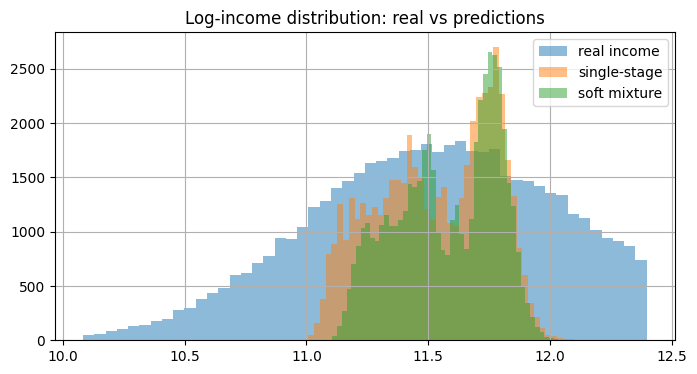

C:\Users\mrx\AppData\Local\Temp\ipykernel_1852\2919136419.py:619: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


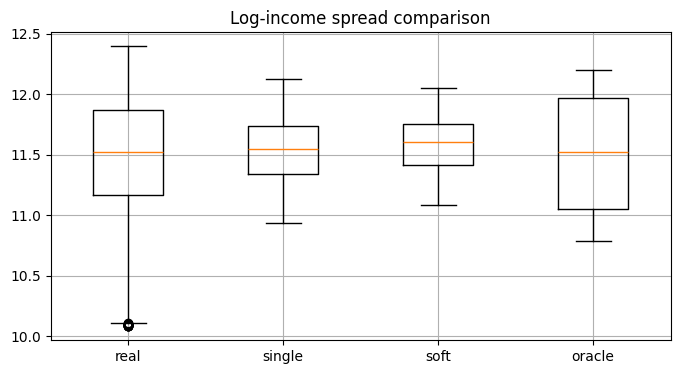


Saved dataset:
processed/v1/train_wide_with_income_base_region_twostage.csv

Saved metrics:
processed/v1/income_metrics_base_region_twostage.csv

Generated income rows: 84330


In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)


# =========================
# CONFIG
# =========================

RAW_PATH = "raw/train_wide_full.csv"
OUTPUT_PATH = "processed/v1/train_wide_with_income_base_region_twostage.csv"
METRICS_PATH = "processed/v1/income_metrics_base_region_twostage.csv"

RANDOM_SEED = 52

TRAIN_INCOME_LOWER_QUANTILE = 0.005
TRAIN_INCOME_UPPER_QUANTILE = 0.90

BUCKET_Q1 = 0.33
BUCKET_Q2 = 0.66


# =========================
# FEATURE ENGINEERING
# =========================

def make_age_group(age):
    if pd.isna(age):
        return "UNKNOWN"
    if age < 18:
        return "UNDER_18"
    if age <= 24:
        return "18_24"
    if age <= 34:
        return "25_34"
    if age <= 44:
        return "35_44"
    if age <= 54:
        return "45_54"
    if age <= 64:
        return "55_64"
    return "65_PLUS"


def safe_category(df, col, default="UNKNOWN"):
    if col in df.columns:
        df[col] = df[col].fillna(default).astype(str)
    else:
        df[col] = default
    return df


def prepare_base_plus_region_features(df):
    df = df.copy()

    # base
    df = df.dropna(subset=["sex"])
    df["sex"] = df["sex"].astype(str)

    df = safe_category(df, "segment")

    # region features
    df = safe_category(df, "pais_residencia")
    df = safe_category(df, "cod_prov")
    df = safe_category(df, "nomprov")

    # seniority
    df["seniority_months"] = pd.to_numeric(df["seniority_months"], errors="coerce")
    df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
    df = df.dropna(subset=["seniority_months"])
    df["seniority_months"] = df["seniority_months"].round().astype("float64")
    df["seniority_years"] = df["seniority_months"] / 12

    # age
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[(df["age"] < 14) | (df["age"] > 95), "age"] = np.nan
    df = df.dropna(subset=["age"])
    df["age"] = df["age"].round().astype("float64")
    df["age_group"] = df["age"].apply(make_age_group)

    # new customer
    df["is_new_customer"] = pd.to_numeric(
        df["is_new_customer"],
        errors="coerce"
    ).fillna(0).astype("float64")

    # product columns
    prefixes = ("dep-", "card-", "rko-", "loan-", "srv-", "biz-")

    product_cols = [
        col for col in df.columns
        if col.startswith(prefixes)
    ]

    for col in product_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float64")

    dep_cols = [col for col in product_cols if col.startswith("dep-")]
    card_cols = [col for col in product_cols if col.startswith("card-")]
    rko_cols = [col for col in product_cols if col.startswith("rko-")]
    loan_cols = [col for col in product_cols if col.startswith("loan-")]
    srv_cols = [col for col in product_cols if col.startswith("srv-")]
    biz_cols = [col for col in product_cols if col.startswith("biz-")]

    df["products_count"] = df[product_cols].sum(axis=1) if product_cols else 0.0

    df["dep_count"] = df[dep_cols].sum(axis=1) if dep_cols else 0.0
    df["card_count"] = df[card_cols].sum(axis=1) if card_cols else 0.0
    df["rko_count"] = df[rko_cols].sum(axis=1) if rko_cols else 0.0
    df["loan_count"] = df[loan_cols].sum(axis=1) if loan_cols else 0.0
    df["srv_count"] = df[srv_cols].sum(axis=1) if srv_cols else 0.0
    df["biz_count"] = df[biz_cols].sum(axis=1) if biz_cols else 0.0

    df["has_dep"] = (df["dep_count"] > 0).astype(int)
    df["has_card"] = (df["card_count"] > 0).astype(int)
    df["has_rko"] = (df["rko_count"] > 0).astype(int)
    df["has_loan"] = (df["loan_count"] > 0).astype(int)
    df["has_srv"] = (df["srv_count"] > 0).astype(int)
    df["has_biz"] = (df["biz_count"] > 0).astype(int)

    df["products_per_seniority_year"] = (
        df["products_count"] / (df["seniority_years"] + 1)
    )

    def product_profile(row):
        if row["products_count"] == 0:
            return "NO_PRODUCTS"

        profile = []

        if row["has_dep"]:
            profile.append("DEP")
        if row["has_card"]:
            profile.append("CARD")
        if row["has_rko"]:
            profile.append("RKO")
        if row["has_loan"]:
            profile.append("LOAN")
        if row["has_srv"]:
            profile.append("SRV")
        if row["has_biz"]:
            profile.append("BIZ")

        return "_".join(profile)

    df["product_profile"] = df.apply(product_profile, axis=1)

    return df, product_cols


# =========================
# METRICS
# =========================

def calculate_metrics(y_true, y_pred, title):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    medae = median_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmsle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {title} ===")
    print(f"Rows: {len(y_true):,}")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MedianAE: {medae:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R2: {r2:.4f}")

    return {
        "title": title,
        "rows": len(y_true),
        "mae": mae,
        "rmse": rmse,
        "median_ae": medae,
        "mape": mape,
        "rmsle": rmsle,
        "r2": r2
    }


def distribution_report(y_true, y_pred, title):
    y_true_log = np.log1p(y_true)
    y_pred_log = np.log1p(np.maximum(y_pred, 0))

    return {
        "title": title,
        "true_log_std": np.std(y_true_log),
        "pred_log_std": np.std(y_pred_log),
        "true_q05": np.quantile(y_true, 0.05),
        "pred_q05": np.quantile(y_pred, 0.05),
        "true_q50": np.quantile(y_true, 0.50),
        "pred_q50": np.quantile(y_pred, 0.50),
        "true_q95": np.quantile(y_true, 0.95),
        "pred_q95": np.quantile(y_pred, 0.95),
    }


# =========================
# LOAD DATA
# =========================

df = pd.read_csv(RAW_PATH)
original_cols = df.columns.tolist()

print("Original rows:", len(df))
print("Original columns:", len(df.columns))

df, product_cols = prepare_base_plus_region_features(df)

print("Rows after feature preparation:", len(df))
print("Product columns:", product_cols)

known_mask = df["income"].notna() & (df["income"] > 0)
known_df_raw = df.loc[known_mask].copy()

lower = known_df_raw["income"].quantile(TRAIN_INCOME_LOWER_QUANTILE)
upper = known_df_raw["income"].quantile(TRAIN_INCOME_UPPER_QUANTILE)

known_df = known_df_raw[
    (known_df_raw["income"] >= lower) &
    (known_df_raw["income"] <= upper)
].copy()

print("\nIncome cut:")
print(f"Lower q{TRAIN_INCOME_LOWER_QUANTILE}: {lower:,.2f}")
print(f"Upper q{TRAIN_INCOME_UPPER_QUANTILE}: {upper:,.2f}")
print("Known rows before cut:", len(known_df_raw))
print("Known rows after cut:", len(known_df))
print("Removed rows:", len(known_df_raw) - len(known_df))

known_df = known_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


# =========================
# FEATURES
# =========================

cat_features = [
    "sex",
    "segment",
    "age_group",
    "product_profile",

    "pais_residencia",
    "cod_prov",
    "nomprov"
]

num_features = [
    "age",
    "is_new_customer",
    "seniority_months",
    "seniority_years",

    "products_count",
    "dep_count",
    "card_count",
    "rko_count",
    "loan_count",
    "srv_count",
    "biz_count",

    "has_dep",
    "has_card",
    "has_rko",
    "has_loan",
    "has_srv",
    "has_biz",

    "products_per_seniority_year",
] + product_cols

features = cat_features + num_features

for col in cat_features:
    df[col] = df[col].fillna("UNKNOWN").astype(str)
    known_df[col] = known_df[col].fillna("UNKNOWN").astype(str)

for col in num_features:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float64")
    known_df[col] = pd.to_numeric(known_df[col], errors="coerce").fillna(0).astype("float64")


# =========================
# SPLIT
# =========================

segment_counts = known_df["segment"].value_counts()
stratify_col = known_df["segment"] if segment_counts.min() >= 2 else None

train_df, test_df = train_test_split(
    known_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=stratify_col
)

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))

X_train = train_df[features]
y_train = train_df["income"]

X_test = test_df[features]
y_test = test_df["income"]

X_all = df[features]


# =========================
# BUCKETS
# =========================

q1 = y_train.quantile(BUCKET_Q1)
q2 = y_train.quantile(BUCKET_Q2)

print("\nIncome bucket thresholds:")
print(f"LOW <= {q1:,.2f}")
print(f"MID <= {q2:,.2f}")
print(f"HIGH > {q2:,.2f}")


def make_income_bucket(income):
    if income <= q1:
        return 0
    if income <= q2:
        return 1
    return 2


bucket_names = {
    0: "LOW",
    1: "MID",
    2: "HIGH"
}

train_df["income_bucket"] = train_df["income"].apply(make_income_bucket)
test_df["income_bucket"] = test_df["income"].apply(make_income_bucket)

print("\nTrain bucket counts:")
print(train_df["income_bucket"].map(bucket_names).value_counts())

print("\nTest bucket counts:")
print(test_df["income_bucket"].map(bucket_names).value_counts())


# =========================
# SINGLE-STAGE CATBOOST
# =========================

single_model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=1500,
    learning_rate=0.04,
    depth=7,
    l2_leaf_reg=7,
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False
)

single_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

single_pred = single_model.predict(X_test)
single_pred = np.clip(single_pred, lower, upper)


# =========================
# BUCKET CLASSIFIER
# =========================

bucket_clf = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="Accuracy",
    iterations=1000,
    learning_rate=0.04,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False
)

bucket_clf.fit(
    X_train,
    train_df["income_bucket"],
    cat_features=cat_features,
    eval_set=(X_test, test_df["income_bucket"]),
    use_best_model=True
)

test_bucket_proba_raw = bucket_clf.predict_proba(X_test)
test_bucket_hard_pred = bucket_clf.predict(X_test).astype(int).reshape(-1)

class_order = bucket_clf.classes_.astype(int)

print("\nClass order:", class_order)

print("\n=== Bucket classification ===")
print("Accuracy:", accuracy_score(test_df["income_bucket"], test_bucket_hard_pred))
print("\nClassification report:")
print(classification_report(
    test_df["income_bucket"],
    test_bucket_hard_pred,
    target_names=["LOW", "MID", "HIGH"]
))
print("\nConfusion matrix:")
print(confusion_matrix(test_df["income_bucket"], test_bucket_hard_pred))


# =========================
# REGRESSOR PER BUCKET
# =========================

bucket_models = {}
bucket_medians = {}

for bucket_id in [0, 1, 2]:
    bucket_train = train_df[train_df["income_bucket"] == bucket_id].copy()

    bucket_median = bucket_train["income"].median()
    bucket_medians[bucket_id] = bucket_median

    print(f"\nTraining regressor for bucket {bucket_names[bucket_id]}")
    print("Rows:", len(bucket_train))
    print("Median income:", f"{bucket_median:,.2f}")

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=1200,
        learning_rate=0.04,
        depth=6,
        l2_leaf_reg=5,
        random_seed=RANDOM_SEED,
        verbose=100,
        allow_writing_files=False
    )

    model.fit(
        bucket_train[features],
        bucket_train["income"],
        cat_features=cat_features
    )

    bucket_models[bucket_id] = model


def predict_all_bucket_regressors(X):
    pred_matrix = np.zeros((len(X), 3))

    for bucket_id in [0, 1, 2]:
        model = bucket_models[bucket_id]

        if model is None:
            pred_matrix[:, bucket_id] = bucket_medians[bucket_id]
        else:
            pred_matrix[:, bucket_id] = model.predict(X)

    return pred_matrix


def align_proba_to_buckets(proba_raw, class_order):
    proba = np.zeros((proba_raw.shape[0], 3))

    for col_idx, class_id in enumerate(class_order):
        proba[:, int(class_id)] = proba_raw[:, col_idx]

    return proba


# =========================
# TWO-STAGE PREDICTIONS
# =========================

test_regressor_preds = predict_all_bucket_regressors(X_test)
test_bucket_proba = align_proba_to_buckets(test_bucket_proba_raw, class_order)

# soft mixture
soft_pred = (
    test_bucket_proba[:, 0] * test_regressor_preds[:, 0] +
    test_bucket_proba[:, 1] * test_regressor_preds[:, 1] +
    test_bucket_proba[:, 2] * test_regressor_preds[:, 2]
)

soft_pred = np.clip(soft_pred, lower, upper)

# hard two-stage
hard_pred = np.zeros(len(X_test))

for bucket_id in [0, 1, 2]:
    mask = test_bucket_hard_pred == bucket_id

    if mask.sum() == 0:
        continue

    hard_pred[mask] = test_regressor_preds[mask, bucket_id]

hard_pred = np.clip(hard_pred, lower, upper)

# oracle bucket
oracle_pred = np.zeros(len(X_test))
true_buckets = test_df["income_bucket"].values

for bucket_id in [0, 1, 2]:
    mask = true_buckets == bucket_id

    if mask.sum() == 0:
        continue

    oracle_pred[mask] = test_regressor_preds[mask, bucket_id]

oracle_pred = np.clip(oracle_pred, lower, upper)

# global median
global_median_pred = np.full(len(y_test), y_train.median())


# =========================
# METRICS
# =========================

single_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=single_pred,
    title="SINGLE-STAGE base_plus_region CatBoost"
)

soft_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=soft_pred,
    title="SOFT MIXTURE base_plus_region CatBoost"
)

hard_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=hard_pred,
    title="HARD TWO-STAGE base_plus_region CatBoost"
)

oracle_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=oracle_pred,
    title="ORACLE bucket base_plus_region CatBoost"
)

median_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=global_median_pred,
    title="GLOBAL MEDIAN baseline"
)

metrics_df = pd.DataFrame({
    "single_stage_test": single_metrics,
    "soft_mixture_test": soft_metrics,
    "hard_two_stage_test": hard_metrics,
    "oracle_bucket_test": oracle_metrics,
    "global_median_test": median_metrics
}).T

print("\nMetrics summary:")
display(metrics_df)


# =========================
# DISTRIBUTION DIAGNOSTICS
# =========================

distribution_df = pd.DataFrame([
    distribution_report(y_test, single_pred, "single_stage"),
    distribution_report(y_test, soft_pred, "soft_mixture"),
    distribution_report(y_test, hard_pred, "hard_two_stage"),
    distribution_report(y_test, oracle_pred, "oracle_bucket"),
    distribution_report(y_test, global_median_pred, "global_median"),
])

print("\nDistribution diagnostics:")
display(distribution_df)

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(y_test), bins=50, alpha=0.5, label="real income")
plt.hist(np.log1p(single_pred), bins=50, alpha=0.5, label="single-stage")
plt.hist(np.log1p(soft_pred), bins=50, alpha=0.5, label="soft mixture")
plt.legend()
plt.grid(True)
plt.title("Log-income distribution: real vs predictions")
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(
    [
        np.log1p(y_test),
        np.log1p(single_pred),
        np.log1p(soft_pred),
        np.log1p(oracle_pred)
    ],
    labels=[
        "real",
        "single",
        "soft",
        "oracle"
    ]
)
plt.grid(True)
plt.title("Log-income spread comparison")
plt.show()


# =========================
# GENERATE FULL DATASET WITH BEST PRACTICAL MODEL
# =========================
# Практически обычно выбираем single-stage, если soft не лучше по MAE.
# Если soft окажется лучше, можно поменять USE_MODEL_FOR_GENERATION на "soft".

USE_MODEL_FOR_GENERATION = "single"  # "single" or "soft"

if USE_MODEL_FOR_GENERATION == "single":
    pred_all = single_model.predict(X_all)
elif USE_MODEL_FOR_GENERATION == "soft":
    all_bucket_proba_raw = bucket_clf.predict_proba(X_all)
    all_bucket_proba = align_proba_to_buckets(all_bucket_proba_raw, class_order)
    all_regressor_preds = predict_all_bucket_regressors(X_all)

    pred_all = (
        all_bucket_proba[:, 0] * all_regressor_preds[:, 0] +
        all_bucket_proba[:, 1] * all_regressor_preds[:, 1] +
        all_bucket_proba[:, 2] * all_regressor_preds[:, 2]
    )
else:
    raise ValueError("USE_MODEL_FOR_GENERATION must be 'single' or 'soft'.")

pred_all = np.clip(pred_all, lower, upper)

df["income_model_prediction"] = np.round(pred_all, 2)

missing_mask = df["income"].isna() | (df["income"] <= 0)

df["income_generated"] = np.nan
df.loc[missing_mask, "income_generated"] = df.loc[
    missing_mask,
    "income_model_prediction"
]

df["income_filled"] = df["income"]
df.loc[missing_mask, "income_filled"] = df.loc[
    missing_mask,
    "income_generated"
]

df["income_was_generated"] = missing_mask.astype(int)


# =========================
# SAVE
# =========================

extra_cols = [
    "income_model_prediction",
    "income_generated",
    "income_filled",
    "income_was_generated"
]

output_cols = []

for col in original_cols:
    if col in df.columns:
        output_cols.append(col)

for col in extra_cols:
    if col in df.columns and col not in output_cols:
        output_cols.append(col)

df_out = df[output_cols].copy()

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_out.to_csv(OUTPUT_PATH, index=False)
metrics_df.to_csv(METRICS_PATH, index=True)

print("\nSaved dataset:")
print(OUTPUT_PATH)

print("\nSaved metrics:")
print(METRICS_PATH)

print("\nGenerated income rows:", int(df_out["income_was_generated"].sum()))

In [13]:
df = pd.read_csv('raw/train_wide_full.csv')
df.head()

C:\Users\mrx\AppData\Local\Temp\ipykernel_1852\392427276.py:1: DtypeWarning: Columns (0: ult_fec_cli_1t, 1: indrel_1mes, 2: conyuemp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('raw/train_wide_full.csv')


,fecha_dato,user_id,ind_empleado,pais_residencia,sex,age,fecha_alta,is_new_customer,seniority_months,indrel,...,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3,ind_recibo_ult1
0,2016-05-28,657788,N,ES,F,42,2006-11-18,0.0,114,1.0,...,0,0,0,0,0,0,0,0,0,0
1,2016-05-28,657795,N,ES,M,44,2006-11-18,0.0,114,1.0,...,0,0,0,0,0,0,0,0,0,0
2,2016-05-28,657790,N,ES,M,42,2006-11-18,0.0,114,1.0,...,0,0,0,0,1,0,0,1,1,1
3,2016-05-28,657794,N,ES,F,49,2006-11-18,0.0,114,1.0,...,0,0,0,0,0,0,0,0,0,0
4,2016-05-28,657789,N,ES,M,36,2006-11-18,0.0,91,1.0,...,0,0,0,0,1,0,0,0,0,0


In [14]:
df['cod_prov'].value_counts()

cod_prov
28.0    144676
8.0      29270
46.0     17138
41.0     14846
15.0     12771
3.0       8244
36.0      8140
50.0      8040
29.0      7883
47.0      7380
30.0      7310
11.0      6317
33.0      6138
35.0      5799
48.0      5508
37.0      5101
39.0      4999
45.0      4959
18.0      4153
13.0      3408
2.0       3373
7.0       3266
14.0      3240
6.0       3224
9.0       2921
27.0      2869
24.0      2655
12.0      2545
10.0      2526
43.0      2523
26.0      2485
32.0      2473
31.0      2365
21.0      2363
20.0      2258
38.0      2237
23.0      1943
19.0      1924
17.0      1853
4.0       1797
49.0      1703
25.0      1702
34.0      1616
16.0      1534
40.0      1413
5.0       1320
1.0       1253
22.0      1077
42.0       558
44.0       551
52.0       267
51.0       227
Name: count, dtype: int64

In [15]:
df['cod_prov'].isna().sum()

np.int64(0)

In [6]:
import pandas as pd
df = pd.read_csv('raw/train_wide_full.csv')
df['nomprov'].value_counts()
df.head()

C:\Users\mrx\AppData\Local\Temp\ipykernel_10852\3257287849.py:2: DtypeWarning: Columns (0: ult_fec_cli_1t, 1: indrel_1mes, 2: conyuemp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('raw/train_wide_full.csv')


,fecha_dato,user_id,ind_empleado,pais_residencia,sex,age,fecha_alta,is_new_customer,seniority_months,indrel,...,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3,ind_recibo_ult1
0,2016-05-28,657788,N,ES,F,42,2006-11-18,0.0,114,1.0,...,0,0,0,0,0,0,0,0,0,0
1,2016-05-28,657795,N,ES,M,44,2006-11-18,0.0,114,1.0,...,0,0,0,0,0,0,0,0,0,0
2,2016-05-28,657790,N,ES,M,42,2006-11-18,0.0,114,1.0,...,0,0,0,0,1,0,0,1,1,1
3,2016-05-28,657794,N,ES,F,49,2006-11-18,0.0,114,1.0,...,0,0,0,0,0,0,0,0,0,0
4,2016-05-28,657789,N,ES,M,36,2006-11-18,0.0,91,1.0,...,0,0,0,0,1,0,0,0,0,0


In [7]:
df.drop(columns=['fecha_dato', 'ind_empleado', 'pais_residencia', 'fecha_alta', 'indrel'], inplace=True)
df.head()

,user_id,sex,age,is_new_customer,seniority_months,ult_fec_cli_1t,indrel_1mes,tiprel_1mes,indresi,indext,...,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3,ind_recibo_ult1
0,657788,F,42,0.0,114,NaN,1,A,S,N,...,0,0,0,0,0,0,0,0,0,0
1,657795,M,44,0.0,114,NaN,1,A,S,N,...,0,0,0,0,0,0,0,0,0,0
2,657790,M,42,0.0,114,NaN,1,A,S,N,...,0,0,0,0,1,0,0,1,1,1
3,657794,F,49,0.0,114,NaN,1,A,S,N,...,0,0,0,0,0,0,0,0,0,0
4,657789,M,36,0.0,91,NaN,1,A,S,N,...,0,0,0,0,1,0,0,0,0,0


In [11]:
df.drop(columns=['ult_fec_cli_1t', 'indrel_1mes', 'indresi', 'indext', 'ind_recibo_ult1'], inplace=True)
df.head()

,user_id,sex,age,is_new_customer,seniority_months,tiprel_1mes,conyuemp,canal_entrada,indfall,tipodom,...,dep-2,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3
0,657788,F,42,0.0,114,A,NaN,KBF,N,1.0,...,0,0,0,0,0,0,0,0,0,0
1,657795,M,44,0.0,114,A,NaN,KAP,N,1.0,...,0,0,0,0,0,0,0,0,0,0
2,657790,M,42,0.0,114,A,NaN,KBF,N,1.0,...,0,0,0,0,0,1,0,0,1,1
3,657794,F,49,0.0,114,A,NaN,KAT,N,1.0,...,0,0,0,0,0,0,0,0,0,0
4,657789,M,36,0.0,91,A,NaN,KAT,N,1.0,...,0,0,0,0,0,1,0,0,0,0


In [12]:
df.drop(columns=['tiprel_1mes', 'conyuemp', 'canal_entrada', 'indfall', 'tipodom'], inplace=True)

In [13]:
df.head()

,user_id,sex,age,is_new_customer,seniority_months,cod_prov,nomprov,ind_actividad_cliente,income,segment,...,dep-2,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3
0,657788,F,42,0.0,114,28.0,MADRID,1.0,132559.35,INDIVIDUALS,...,0,0,0,0,0,0,0,0,0,0
1,657795,M,44,0.0,114,26.0,"RIOJA, LA",1.0,81399.57,INDIVIDUALS,...,0,0,0,0,0,0,0,0,0,0
2,657790,M,42,0.0,114,48.0,BIZKAIA,1.0,NaN,INDIVIDUALS,...,0,0,0,0,0,1,0,0,1,1
3,657794,F,49,0.0,114,8.0,BARCELONA,1.0,102189.00,VIP,...,0,0,0,0,0,0,0,0,0,0
4,657789,M,36,0.0,91,28.0,MADRID,1.0,153725.49,VIP,...,0,0,0,0,0,1,0,0,0,0


In [14]:
df.drop(columns=['ind_actividad_cliente'], inplace=True)

In [15]:
df.head()

,user_id,sex,age,is_new_customer,seniority_months,cod_prov,nomprov,income,segment,dep-7,...,dep-2,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3
0,657788,F,42,0.0,114,28.0,MADRID,132559.35,INDIVIDUALS,0,...,0,0,0,0,0,0,0,0,0,0
1,657795,M,44,0.0,114,26.0,"RIOJA, LA",81399.57,INDIVIDUALS,0,...,0,0,0,0,0,0,0,0,0,0
2,657790,M,42,0.0,114,48.0,BIZKAIA,NaN,INDIVIDUALS,0,...,0,0,0,0,0,1,0,0,1,1
3,657794,F,49,0.0,114,8.0,BARCELONA,102189.00,VIP,0,...,0,0,0,0,0,0,0,0,0,0
4,657789,M,36,0.0,91,28.0,MADRID,153725.49,VIP,0,...,0,0,0,0,0,1,0,0,0,0


In [16]:
df.to_csv('raw/train_wide_new.csv', index=False)

In [17]:
df.drop(columns=['ind_aval_fin_ult1'], inplace=True)

In [18]:
df.rename(columns={'cod_prov': 'region_code', 'nomprov': 'region_name'}, inplace=True)
df.head()

,user_id,sex,age,is_new_customer,seniority_months,region_code,region_name,income,segment,dep-7,...,dep-2,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3
0,657788,F,42,0.0,114,28.0,MADRID,132559.35,INDIVIDUALS,0,...,0,0,0,0,0,0,0,0,0,0
1,657795,M,44,0.0,114,26.0,"RIOJA, LA",81399.57,INDIVIDUALS,0,...,0,0,0,0,0,0,0,0,0,0
2,657790,M,42,0.0,114,48.0,BIZKAIA,NaN,INDIVIDUALS,0,...,0,0,0,0,0,1,0,0,1,1
3,657794,F,49,0.0,114,8.0,BARCELONA,102189.00,VIP,0,...,0,0,0,0,0,0,0,0,0,0
4,657789,M,36,0.0,91,28.0,MADRID,153725.49,VIP,0,...,0,0,0,0,0,1,0,0,0,0


In [19]:
df.to_csv('raw/train_wide_new.csv', index=False)

In [20]:
df['sex'].isna().sum()

np.int64(3)

In [21]:
df.dropna(subset=['sex'], inplace=True)

In [22]:
df['sex'].isna().sum()

np.int64(0)

In [28]:
import numpy as np

# drop 2 negative
df.loc[df["seniority_months"] < 0, "seniority_months"] = np.nan
df['seniority_months'].isna().sum()
df.dropna(subset=['seniority_months'], inplace=True)